In [ ]:
# ============================================================
# 1. Setup for pre-post spatial-accuracy GLM
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib

from IPython.display import display

PROJECT_ROOT = Path("/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project")
DATA_DIR = PROJECT_ROOT / "data"
BIDS_DIR = DATA_DIR / "bids_ackbar"
FMRIPREP_DIR = DATA_DIR / "fmriprep_output"

# Existing primary analyses used as validated inputs
MEMORY_QUALITY_ANALYSIS_NAME = "memory_quality_post_viewing_parametric"
MEMORY_QUALITY_OUT_DIR = DATA_DIR / "processed" / "glm" / MEMORY_QUALITY_ANALYSIS_NAME
MEMORY_QUALITY_TABLE_DIR = MEMORY_QUALITY_OUT_DIR / "tables"

SPATIAL_ONLY_ANALYSIS_NAME = "spatial_accuracy_only_post_viewing_parametric"
SPATIAL_ONLY_OUT_DIR = DATA_DIR / "processed" / "glm" / SPATIAL_ONLY_ANALYSIS_NAME
SPATIAL_ONLY_TABLE_DIR = SPATIAL_ONLY_OUT_DIR / "tables"

# New analysis
ANALYSIS_NAME = "pre_post_spatial_accuracy_parametric"
OUT_DIR = DATA_DIR / "processed" / "glm" / ANALYSIS_NAME
EVENTS_DIR = DATA_DIR / "preprocessed" / "relabeled_events_pre_post_spatial_accuracy"
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
QC_DIR = OUT_DIR / "qc"

for path in [
    OUT_DIR,
    EVENTS_DIR,
    FIG_DIR,
    TABLE_DIR,
    QC_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

# Viewing task definitions
PRE_SESSION = "ses-01"
POST_SESSION = "ses-05"
VIEWING_TASK = "viewing"
VIEWING_RUN = "01"
BOLD_SPACE = "MNI152NLin2009cAsym"

print("Pre-post spatial-accuracy GLM setup complete.")
print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUT_DIR:", OUT_DIR)
print("EVENTS_DIR:", EVENTS_DIR)

In [2]:
# ============================================================
# 2. Load validated behavioral and subject tables
# ============================================================

spatial_behavior_path = (
    SPATIAL_ONLY_TABLE_DIR
    / "final_behavior_item_level_spatial_accuracy_only.csv"
)

analysis_subjects_path = (
    MEMORY_QUALITY_TABLE_DIR
    / "final_analysis_subjects.csv"
)

post_glm_backbone_path = (
    MEMORY_QUALITY_TABLE_DIR
    / "final_all_subjects_glm_events_long.csv"
)

print("Loading:")
print(spatial_behavior_path)
print(analysis_subjects_path)
print(post_glm_backbone_path)

assert spatial_behavior_path.exists(), f"Missing: {spatial_behavior_path}"
assert analysis_subjects_path.exists(), f"Missing: {analysis_subjects_path}"
assert post_glm_backbone_path.exists(), f"Missing: {post_glm_backbone_path}"

spatial_behavior = pd.read_csv(spatial_behavior_path)
analysis_subjects = pd.read_csv(analysis_subjects_path)
post_glm_backbone = pd.read_csv(post_glm_backbone_path)

primary_subjects_final = (
    analysis_subjects
    .loc[analysis_subjects["primary_analysis"].astype(bool), "subject"]
    .tolist()
)

sensitivity_subjects_final = (
    analysis_subjects
    .loc[analysis_subjects["sensitivity_no_high_motion"].astype(bool), "subject"]
    .tolist()
)

print("\nPrimary subjects:", len(primary_subjects_final))
print(primary_subjects_final)

print("\nSensitivity subjects:", len(sensitivity_subjects_final))
print(sensitivity_subjects_final)

print("\nSpatial behavior shape:", spatial_behavior.shape)
print("Post GLM backbone shape:", post_glm_backbone.shape)

print("\nSpatial behavior columns:")
print(spatial_behavior.columns.tolist())

print("\nPost GLM backbone columns:")
print(post_glm_backbone.columns.tolist())

display(spatial_behavior.head())
display(post_glm_backbone.head())

Loading:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/spatial_accuracy_only_post_viewing_parametric/tables/final_behavior_item_level_spatial_accuracy_only.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/final_analysis_subjects.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/memory_quality_post_viewing_parametric/tables/final_all_subjects_glm_events_long.csv



Primary subjects: 28
['sub-P10', 'sub-P12', 'sub-P13', 'sub-P14', 'sub-P15', 'sub-P16', 'sub-P17', 'sub-P18', 'sub-P19', 'sub-P21', 'sub-P22', 'sub-P23', 'sub-P25', 'sub-P27', 'sub-P31', 'sub-P34', 'sub-P35', 'sub-P36', 'sub-P37', 'sub-P41', 'sub-P42', 'sub-P43', 'sub-P44', 'sub-P45', 'sub-P47', 'sub-P48', 'sub-P50', 'sub-P51']

Sensitivity subjects: 26
['sub-P10', 'sub-P12', 'sub-P13', 'sub-P14', 'sub-P15', 'sub-P16', 'sub-P17', 'sub-P18', 'sub-P22', 'sub-P23', 'sub-P25', 'sub-P27', 'sub-P31', 'sub-P34', 'sub-P35', 'sub-P36', 'sub-P37', 'sub-P41', 'sub-P42', 'sub-P43', 'sub-P44', 'sub-P45', 'sub-P47', 'sub-P48', 'sub-P50', 'sub-P51']

Spatial behavior shape: (1045, 18)
Post GLM backbone shape: (18174, 15)

Spatial behavior columns:
['subject', 'image_file', 'spatial_error', 'spatial_accuracy', 'confidence', 'goal_relevant', 'goal_irrelevant', 'recalled_x', 'recalled_z', 'checkpoint_x', 'checkpoint_z', 'spatial_accuracy_z', 'confidence_z', 'memory_quality_raw', 'memory_quality_z', 're

,subject,image_file,spatial_error,spatial_accuracy,confidence,goal_relevant,goal_irrelevant,recalled_x,recalled_z,checkpoint_x,checkpoint_z,spatial_accuracy_z,confidence_z,memory_quality_raw,memory_quality_z,relevance_condition,memory_quality_condition_centered,spatial_accuracy_condition_centered
0,sub-P10,wealth_5_e3_7_nr_o_v1_old.jpg,469.158800,-469.158800,65.0,False,True,-134.2,188.0,-407.7,-193.2,-0.309192,1.166425,0.428616,0.505430,irrelevant,0.549340,-0.046390
1,sub-P10,pirate_6_e2_13_r_h_v1_old.jpg,284.231900,-284.231900,44.0,True,False,-401.5,-192.8,-280.4,64.3,0.462052,0.273381,0.367717,0.433616,relevant,0.400684,0.264951
2,sub-P10,pirate_7_e3_1_nr_h_v1_old.jpg,0.952219,-0.952219,78.0,False,True,-129.3,220.4,-128.5,220.8,1.643481,1.719261,1.681371,1.982695,irrelevant,2.026605,1.906283
3,sub-P10,food_8_e3_13_r_o_v1_old.jpg,333.706200,-333.706200,34.0,True,False,-75.8,-199.3,-280.4,64.3,0.255718,-0.151878,0.051920,0.061225,relevant,0.028292,0.058616
4,sub-P10,viking_3_e2_1_nr_h_v1_old.jpg,112.915500,-112.915500,34.0,False,True,-503.6,-252.8,-407.7,-193.2,1.176534,-0.151878,0.512328,0.604144,irrelevant,0.648054,1.439336


,subject,onset,duration,image_file,memory_quality_z,memory_quality_condition_centered,spatial_accuracy_z,confidence_z,goal_relevant,goal_irrelevant,relevance_condition,likely_water_placement,valid_spatial_placement,trial_type,modulation
0,sub-P10,4.632,3.034,maya_3_e3_6_r_h_v1_old.jpg,NaN,NaN,NaN,NaN,False,False,NaN,False,False,old_other_no_memory_quality,1.000000
1,sub-P10,10.815,3.017,wealth_5_e3_7_nr_o_v1_old.jpg,0.505430,0.549340,-0.309192,1.166425,False,True,irrelevant,False,True,old_irrelevant_valid_main,1.000000
2,sub-P10,10.815,3.017,wealth_5_e3_7_nr_o_v1_old.jpg,0.505430,0.549340,-0.309192,1.166425,False,True,irrelevant,False,True,old_irrelevant_memory_quality,0.549340
3,sub-P10,17.065,3.017,pirate_6_e2_13_r_h_v1_old.jpg,0.433616,0.400684,0.462052,0.273381,True,False,relevant,False,True,old_relevant_valid_main,1.000000
4,sub-P10,17.065,3.017,pirate_6_e2_13_r_h_v1_old.jpg,0.433616,0.400684,0.462052,0.273381,True,False,relevant,False,True,old_relevant_memory_quality,0.400684


In [3]:
# ============================================================
# 3. Define pre-post spatial-accuracy hypothesis and contrasts
# ============================================================

PRE_POST_SPATIAL_CONTRASTS = {
    # Primary contrast:
    # Does the spatial-accuracy slope increase from pre to post?
    "post_gt_pre_spatial_accuracy": {
        "post_relevant_spatial_accuracy": 0.5,
        "post_irrelevant_spatial_accuracy": 0.5,
        "pre_relevant_spatial_accuracy": -0.5,
        "pre_irrelevant_spatial_accuracy": -0.5,
    },

    # Secondary condition-specific effects
    "post_gt_pre_relevant_spatial_accuracy": {
        "post_relevant_spatial_accuracy": 1.0,
        "pre_relevant_spatial_accuracy": -1.0,
    },

    "post_gt_pre_irrelevant_spatial_accuracy": {
        "post_irrelevant_spatial_accuracy": 1.0,
        "pre_irrelevant_spatial_accuracy": -1.0,
    },

    # Secondary relevance interaction:
    # Is the pre-post spatial-accuracy slope increase stronger for relevant images?
    "relevant_gt_irrelevant_post_gt_pre_spatial_accuracy": {
        "post_relevant_spatial_accuracy": 1.0,
        "pre_relevant_spatial_accuracy": -1.0,
        "post_irrelevant_spatial_accuracy": -1.0,
        "pre_irrelevant_spatial_accuracy": 1.0,
    },

    # Optional main post effect, for comparison with previous notebook
    "post_spatial_accuracy_positive": {
        "post_relevant_spatial_accuracy": 0.5,
        "post_irrelevant_spatial_accuracy": 0.5,
    },

    # Optional main pre effect, useful as baseline check
    "pre_spatial_accuracy_positive": {
        "pre_relevant_spatial_accuracy": 0.5,
        "pre_irrelevant_spatial_accuracy": 0.5,
    },
}

contrast_priority = {
    "post_gt_pre_spatial_accuracy": "primary",
    "post_gt_pre_relevant_spatial_accuracy": "secondary_condition_specific",
    "post_gt_pre_irrelevant_spatial_accuracy": "secondary_condition_specific",
    "relevant_gt_irrelevant_post_gt_pre_spatial_accuracy": "secondary_interaction",
    "post_spatial_accuracy_positive": "descriptive_post_only_check",
    "pre_spatial_accuracy_positive": "descriptive_pre_only_check",
}

contrast_interpretations = {
    "post_gt_pre_spatial_accuracy": (
        "Primary: the relationship between BOLD and later spatial accuracy is stronger after than before learning."
    ),
    "post_gt_pre_relevant_spatial_accuracy": (
        "Secondary: post > pre increase in the spatial-accuracy slope among goal-relevant images."
    ),
    "post_gt_pre_irrelevant_spatial_accuracy": (
        "Secondary: post > pre increase in the spatial-accuracy slope among goal-irrelevant images."
    ),
    "relevant_gt_irrelevant_post_gt_pre_spatial_accuracy": (
        "Secondary interaction: the post > pre spatial-accuracy slope increase is stronger for relevant than irrelevant images."
    ),
    "post_spatial_accuracy_positive": (
        "Descriptive check: positive post-viewing spatial-accuracy slope."
    ),
    "pre_spatial_accuracy_positive": (
        "Descriptive check: positive pre-viewing spatial-accuracy slope."
    ),
}

contrast_summary = pd.DataFrame([
    {
        "contrast": name,
        "priority": contrast_priority[name],
        "weights": str(weights),
        "interpretation": contrast_interpretations[name],
    }
    for name, weights in PRE_POST_SPATIAL_CONTRASTS.items()
])

display(contrast_summary)

contrast_summary_path = TABLE_DIR / "pre_post_spatial_accuracy_contrast_summary.csv"
contrast_summary.to_csv(contrast_summary_path, index=False)

print("Saved:", contrast_summary_path)

,contrast,priority,weights,interpretation
0,post_gt_pre_spatial_accuracy,primary,"{'post_relevant_spatial_accuracy': 0.5, 'post_...",Primary: the relationship between BOLD and lat...
1,post_gt_pre_relevant_spatial_accuracy,secondary_condition_specific,"{'post_relevant_spatial_accuracy': 1.0, 'pre_r...",Secondary: post > pre increase in the spatial-...
2,post_gt_pre_irrelevant_spatial_accuracy,secondary_condition_specific,"{'post_irrelevant_spatial_accuracy': 1.0, 'pre...",Secondary: post > pre increase in the spatial-...
3,relevant_gt_irrelevant_post_gt_pre_spatial_acc...,secondary_interaction,"{'post_relevant_spatial_accuracy': 1.0, 'pre_r...",Secondary interaction: the post > pre spatial-...
4,post_spatial_accuracy_positive,descriptive_post_only_check,"{'post_relevant_spatial_accuracy': 0.5, 'post_...",Descriptive check: positive post-viewing spati...
5,pre_spatial_accuracy_positive,descriptive_pre_only_check,"{'pre_relevant_spatial_accuracy': 0.5, 'pre_ir...",Descriptive check: positive pre-viewing spatia...


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/tables/pre_post_spatial_accuracy_contrast_summary.csv


In [4]:
# ============================================================
# 4. Discover available pre and post viewing files
# ============================================================

def find_bold_candidates(subject, session):
    func_dir = FMRIPREP_DIR / subject / session / "func"
    if not func_dir.exists():
        return []
    
    pattern = (
        f"{subject}_{session}_task-{VIEWING_TASK}_*_space-{BOLD_SPACE}_desc-preproc_bold.nii.gz"
    )
    return sorted(func_dir.glob(pattern))


def find_events_candidates(subject, session):
    func_dir = BIDS_DIR / subject / session / "func"
    if not func_dir.exists():
        return []
    
    pattern = f"{subject}_{session}_task-{VIEWING_TASK}_*_events.tsv"
    return sorted(func_dir.glob(pattern))


discovery_rows = []

for subject in primary_subjects_final:
    pre_bold_candidates = find_bold_candidates(subject, PRE_SESSION)
    post_bold_candidates = find_bold_candidates(subject, POST_SESSION)
    
    pre_event_candidates = find_events_candidates(subject, PRE_SESSION)
    post_event_candidates = find_events_candidates(subject, POST_SESSION)
    
    discovery_rows.append({
        "subject": subject,
        "n_pre_bold_candidates": len(pre_bold_candidates),
        "pre_bold_candidates": ";".join(str(p) for p in pre_bold_candidates),
        "n_post_bold_candidates": len(post_bold_candidates),
        "post_bold_candidates": ";".join(str(p) for p in post_bold_candidates),
        "n_pre_event_candidates": len(pre_event_candidates),
        "pre_event_candidates": ";".join(str(p) for p in pre_event_candidates),
        "n_post_event_candidates": len(post_event_candidates),
        "post_event_candidates": ";".join(str(p) for p in post_event_candidates),
    })

discovery_df = pd.DataFrame(discovery_rows)

display(discovery_df)

discovery_path = TABLE_DIR / "pre_post_viewing_file_discovery.csv"
discovery_df.to_csv(discovery_path, index=False)

print("Saved:", discovery_path)

print("\nSummary:")
display(
    discovery_df[
        [
            "n_pre_bold_candidates",
            "n_post_bold_candidates",
            "n_pre_event_candidates",
            "n_post_event_candidates",
        ]
    ].describe()
)

,subject,n_pre_bold_candidates,pre_bold_candidates,n_post_bold_candidates,post_bold_candidates,n_pre_event_candidates,pre_event_candidates,n_post_event_candidates,post_event_candidates
0,sub-P10,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
1,sub-P12,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
2,sub-P13,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
3,sub-P14,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
4,sub-P15,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
5,sub-P16,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
6,sub-P17,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
7,sub-P18,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
8,sub-P19,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
9,sub-P21,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1,/media/RCPNAS/Data3/Alison_island/kroczak/isla...


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/tables/pre_post_viewing_file_discovery.csv

Summary:


,n_pre_bold_candidates,n_post_bold_candidates,n_pre_event_candidates,n_post_event_candidates
count,28.0,28.0,28.0,28.0
mean,1.0,1.0,1.0,1.0
std,0.0,0.0,0.0,0.0
min,1.0,1.0,1.0,1.0
25%,1.0,1.0,1.0,1.0
50%,1.0,1.0,1.0,1.0
75%,1.0,1.0,1.0,1.0
max,1.0,1.0,1.0,1.0


In [5]:
# ============================================================
# 5. Define file getters and validate exact pre/post files
# ============================================================

def expected_bold_file(subject, session, run=VIEWING_RUN, space=BOLD_SPACE):
    return (
        FMRIPREP_DIR
        / subject
        / session
        / "func"
        / f"{subject}_{session}_task-{VIEWING_TASK}_run-{run}_space-{space}_desc-preproc_bold.nii.gz"
    )


def expected_raw_events_file(subject, session, run=VIEWING_RUN):
    return (
        BIDS_DIR
        / subject
        / session
        / "func"
        / f"{subject}_{session}_task-{VIEWING_TASK}_run-{run}_events.tsv"
    )


file_qc_rows = []

for subject in primary_subjects_final:
    pre_bold = expected_bold_file(subject, PRE_SESSION)
    post_bold = expected_bold_file(subject, POST_SESSION)
    pre_events = expected_raw_events_file(subject, PRE_SESSION)
    post_events = expected_raw_events_file(subject, POST_SESSION)
    
    file_qc_rows.append({
        "subject": subject,
        "pre_bold_exists": pre_bold.exists(),
        "post_bold_exists": post_bold.exists(),
        "pre_events_exists": pre_events.exists(),
        "post_events_exists": post_events.exists(),
        "pre_bold_path": str(pre_bold),
        "post_bold_path": str(post_bold),
        "pre_events_path": str(pre_events),
        "post_events_path": str(post_events),
    })

file_qc = pd.DataFrame(file_qc_rows)

display(file_qc)

missing_file_qc = file_qc.loc[
    (~file_qc["pre_bold_exists"])
    | (~file_qc["post_bold_exists"])
    | (~file_qc["pre_events_exists"])
    | (~file_qc["post_events_exists"])
].copy()

print("\nSubjects with missing exact files:")
display(missing_file_qc)

file_qc_path = TABLE_DIR / "pre_post_exact_file_availability_qc.csv"
file_qc.to_csv(file_qc_path, index=False)

print("Saved:", file_qc_path)

assert missing_file_qc.empty, (
    "Some exact pre/post files are missing. Inspect Cell 4 discovery output before continuing."
)

,subject,pre_bold_exists,post_bold_exists,pre_events_exists,post_events_exists,pre_bold_path,post_bold_path,pre_events_path,post_events_path
0,sub-P10,True,True,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
1,sub-P12,True,True,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
2,sub-P13,True,True,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
3,sub-P14,True,True,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
4,sub-P15,True,True,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
5,sub-P16,True,True,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
6,sub-P17,True,True,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
7,sub-P18,True,True,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
8,sub-P19,True,True,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
9,sub-P21,True,True,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...



Subjects with missing exact files:


,subject,pre_bold_exists,post_bold_exists,pre_events_exists,post_events_exists,pre_bold_path,post_bold_path,pre_events_path,post_events_path


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/tables/pre_post_exact_file_availability_qc.csv


In [6]:
# ============================================================
# 6. Inspect raw pre and post events for one subject
# ============================================================

test_subject = "sub-P15"

pre_events_raw = pd.read_csv(
    expected_raw_events_file(test_subject, PRE_SESSION),
    sep="\t",
)

post_events_raw = pd.read_csv(
    expected_raw_events_file(test_subject, POST_SESSION),
    sep="\t",
)

print("Pre events raw shape:", pre_events_raw.shape)
print("Post events raw shape:", post_events_raw.shape)

print("\nPre events columns:")
print(pre_events_raw.columns.tolist())

print("\nPost events columns:")
print(post_events_raw.columns.tolist())

print("\nPre events head:")
display(pre_events_raw.head(20))

print("\nPost events head:")
display(post_events_raw.head(20))

if "trial_type" in pre_events_raw.columns:
    print("\nPre trial_type counts:")
    display(pre_events_raw["trial_type"].value_counts().rename_axis("trial_type").reset_index(name="n"))

if "trial_type" in post_events_raw.columns:
    print("\nPost trial_type counts:")
    display(post_events_raw["trial_type"].value_counts().rename_axis("trial_type").reset_index(name="n"))

# Image-file columns can have different names depending on the preprocessing script.
possible_image_cols = [
    "image_file",
    "stimulus",
    "stim_file",
    "stimulus_file",
    "file",
    "filename",
]

print("\nCandidate image columns in pre:")
print([col for col in possible_image_cols if col in pre_events_raw.columns])

print("\nCandidate image columns in post:")
print([col for col in possible_image_cols if col in post_events_raw.columns])

Pre events raw shape: (384, 7)
Post events raw shape: (384, 7)

Pre events columns:
['onset', 'duration', 'event', 'button_pressed', 'answer', 'HumanAppearOnThe', 'reaction_time']

Post events columns:
['onset', 'duration', 'event', 'button_pressed', 'answer', 'HumanAppearOnThe', 'reaction_time']

Pre events head:


,onset,duration,event,button_pressed,answer,HumanAppearOnThe,reaction_time
0,4.631,3.033,wealth_4_e1_4_nr_o_v3_old.jpg,1,2.0,Left,1.314
1,11.214,3.016,maya_12_e1_1_r_h_v3_old.jpg,1,1.0,Left,0.545
2,17.397,3.017,pirate_8_e1_10_nr_h_v3_old.jpg,1,1.0,Left,0.610
3,24.047,3.017,maya_4_e1_5_r_h_v3_old.jpg,1,1.0,Left,0.821
4,30.314,3.016,pirate_5_e3_16_r_h_v3_old.jpg,1,1.0,Left,0.736
5,37.297,3.016,drink_4_e2_5_r_o_v3_old.jpg,1,2.0,Left,0.682
6,43.830,3.017,pirate_4_e3_8_r_h_v3_old.jpg,1,1.0,Left,0.945
7,49.613,3.017,pirate_10_new.jpg,1,1.0,Left,0.772
8,55.230,3.017,pirate_13_e2_6_nr_h_v3_old.jpg,1,1.0,Left,0.598
9,61.680,3.016,wealth_9_new.jpg,1,2.0,Left,0.966



Post events head:


,onset,duration,event,button_pressed,answer,HumanAppearOnThe,reaction_time
0,4.622,3.016,wealth_4_e1_4_nr_o_v3_old.jpg,1,2.0,Left,0.946
1,10.806,3.016,maya_12_e1_1_r_h_v3_old.jpg,1,1.0,Left,0.606
2,17.055,3.017,pirate_8_e1_10_nr_h_v3_old.jpg,1,1.0,Left,0.496
3,23.588,3.017,maya_4_e1_5_r_h_v3_old.jpg,1,1.0,Left,0.557
4,29.588,3.017,pirate_5_e3_16_r_h_v3_old.jpg,1,1.0,Left,0.648
5,36.488,3.017,drink_4_e2_5_r_o_v3_old.jpg,1,2.0,Left,0.682
6,43.021,3.017,pirate_4_e3_8_r_h_v3_old.jpg,1,1.0,Left,0.642
7,48.504,3.017,pirate_10_new.jpg,1,1.0,Left,0.699
8,54.054,3.017,pirate_13_e2_6_nr_h_v3_old.jpg,1,1.0,Left,0.347
9,60.238,3.016,wealth_9_new.jpg,1,2.0,Left,0.440



Candidate image columns in pre:
[]

Candidate image columns in post:
[]


In [7]:
# ============================================================
# 7. Robust image-column detection and event cleaning helpers
# Corrected: raw BIDS files use "event" as image filename
# ============================================================

possible_image_cols = [
    "image_file",
    "event",          # <-- important for this dataset
    "stimulus",
    "stim_file",
    "stimulus_file",
    "file",
    "filename",
]

def detect_image_column(events_df):
    candidate_cols = [col for col in possible_image_cols if col in events_df.columns]
    
    if len(candidate_cols) == 0:
        raise ValueError(
            f"No image-file column found. Columns are: {events_df.columns.tolist()}"
        )
    
    # Prefer image_file if available, otherwise event for this dataset.
    if "image_file" in candidate_cols:
        return "image_file"
    
    if "event" in candidate_cols:
        return "event"
    
    return candidate_cols[0]


def normalize_image_filename(value):
    """
    Make image filename comparable across raw BIDS events and behavioral tables.
    """
    if pd.isna(value):
        return np.nan
    
    value = str(value)
    value = value.replace("\\", "/")
    value = value.split("/")[-1]
    
    return value


def prepare_raw_viewing_events(subject, session, run=VIEWING_RUN):
    events_path = expected_raw_events_file(subject, session, run=run)
    assert events_path.exists(), f"Missing raw events: {events_path}"
    
    events = pd.read_csv(events_path, sep="\t")
    
    image_col = detect_image_column(events)
    
    required_cols = ["onset", "duration", image_col]
    missing = [col for col in required_cols if col not in events.columns]
    assert len(missing) == 0, f"{subject} {session}: missing required columns {missing}"
    
    clean = events.copy()
    clean["image_file"] = clean[image_col].apply(normalize_image_filename)
    
    # Keep image-presentation rows only.
    clean = clean.loc[clean["image_file"].notna()].copy()
    
    clean["subject"] = subject
    clean["session"] = session
    clean["run"] = run
    
    # Preserve the original column name for QC.
    clean["source_image_column"] = image_col
    
    return clean


# Quick test on sub-P15
test_pre = prepare_raw_viewing_events("sub-P15", PRE_SESSION)
test_post = prepare_raw_viewing_events("sub-P15", POST_SESSION)

print("Helper functions ready.")
print("sub-P15 pre shape:", test_pre.shape)
print("sub-P15 post shape:", test_post.shape)
print("Detected pre image column:", test_pre["source_image_column"].iloc[0])
print("Detected post image column:", test_post["source_image_column"].iloc[0])

display(test_pre[["onset", "duration", "event", "image_file"]].head())
display(test_post[["onset", "duration", "event", "image_file"]].head())

Helper functions ready.
sub-P15 pre shape: (384, 12)
sub-P15 post shape: (384, 12)
Detected pre image column: event
Detected post image column: event


,onset,duration,event,image_file
0,4.631,3.033,wealth_4_e1_4_nr_o_v3_old.jpg,wealth_4_e1_4_nr_o_v3_old.jpg
1,11.214,3.016,maya_12_e1_1_r_h_v3_old.jpg,maya_12_e1_1_r_h_v3_old.jpg
2,17.397,3.017,pirate_8_e1_10_nr_h_v3_old.jpg,pirate_8_e1_10_nr_h_v3_old.jpg
3,24.047,3.017,maya_4_e1_5_r_h_v3_old.jpg,maya_4_e1_5_r_h_v3_old.jpg
4,30.314,3.016,pirate_5_e3_16_r_h_v3_old.jpg,pirate_5_e3_16_r_h_v3_old.jpg


,onset,duration,event,image_file
0,4.622,3.016,wealth_4_e1_4_nr_o_v3_old.jpg,wealth_4_e1_4_nr_o_v3_old.jpg
1,10.806,3.016,maya_12_e1_1_r_h_v3_old.jpg,maya_12_e1_1_r_h_v3_old.jpg
2,17.055,3.017,pirate_8_e1_10_nr_h_v3_old.jpg,pirate_8_e1_10_nr_h_v3_old.jpg
3,23.588,3.017,maya_4_e1_5_r_h_v3_old.jpg,maya_4_e1_5_r_h_v3_old.jpg
4,29.588,3.017,pirate_5_e3_16_r_h_v3_old.jpg,pirate_5_e3_16_r_h_v3_old.jpg


In [8]:
# ============================================================
# 8. Build pre/post spatial-accuracy modulator table
# ============================================================

# We need one row per subject × image_file with the final spatial-accuracy score.
required_cols = [
    "subject",
    "image_file",
    "relevance_condition",
    "spatial_accuracy_z",
    "spatial_accuracy_condition_centered",
]

missing_cols = [col for col in required_cols if col not in spatial_behavior.columns]
assert len(missing_cols) == 0, f"Missing columns in spatial_behavior: {missing_cols}"

modulator_table = spatial_behavior[required_cols].copy()

# Check uniqueness.
dupes = (
    modulator_table
    .groupby(["subject", "image_file"])
    .size()
    .reset_index(name="n")
    .query("n > 1")
)

print("Duplicate subject × image_file rows:")
display(dupes)

assert len(dupes) == 0, "Modulator table has duplicated subject × image_file rows."

print("Modulator table shape:", modulator_table.shape)

display(
    modulator_table
    .groupby("relevance_condition")
    .agg(
        n_images=("image_file", "count"),
        n_subjects=("subject", "nunique"),
        mean_modulator=("spatial_accuracy_condition_centered", "mean"),
        sd_modulator=("spatial_accuracy_condition_centered", "std"),
        min_modulator=("spatial_accuracy_condition_centered", "min"),
        max_modulator=("spatial_accuracy_condition_centered", "max"),
    )
    .reset_index()
)

modulator_table_path = TABLE_DIR / "pre_post_spatial_accuracy_modulator_table.csv"
modulator_table.to_csv(modulator_table_path, index=False)

print("Saved:", modulator_table_path)

Duplicate subject × image_file rows:


,subject,image_file,n


Modulator table shape: (1045, 5)


,relevance_condition,n_images,n_subjects,mean_modulator,sd_modulator,min_modulator,max_modulator
0,irrelevant,505,28,-8.134307e-18,1.025578,-3.463459,1.996332
1,relevant,540,28,-4.934325e-18,0.952183,-3.276716,1.789849


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/tables/pre_post_spatial_accuracy_modulator_table.csv


In [9]:
# ============================================================
# 8b. Diagnostic check: pre/post image matching
# ============================================================

pre_post_matching_rows = []
pre_post_mismatch_examples = []

for subject in primary_subjects_final:
    pre_raw = prepare_raw_viewing_events(subject, PRE_SESSION)
    post_raw = prepare_raw_viewing_events(subject, POST_SESSION)
    
    pre_images = pre_raw["image_file"].tolist()
    post_images = post_raw["image_file"].tolist()
    
    pre_set = set(pre_images)
    post_set = set(post_images)
    
    same_length = len(pre_images) == len(post_images)
    same_order = same_length and all(a == b for a, b in zip(pre_images, post_images))
    same_set = pre_set == post_set
    
    pre_only = sorted(pre_set - post_set)
    post_only = sorted(post_set - pre_set)
    
    # Check only the modulator images for this subject.
    subject_modulator_images = set(
        modulator_table.loc[
            modulator_table["subject"] == subject,
            "image_file"
        ]
    )
    
    modulator_in_pre = subject_modulator_images.intersection(pre_set)
    modulator_in_post = subject_modulator_images.intersection(post_set)
    modulator_in_both = subject_modulator_images.intersection(pre_set).intersection(post_set)
    
    pre_post_matching_rows.append({
        "subject": subject,
        "n_pre_rows": len(pre_images),
        "n_post_rows": len(post_images),
        "n_pre_unique_images": len(pre_set),
        "n_post_unique_images": len(post_set),
        "same_order": same_order,
        "same_set": same_set,
        "n_images_in_both": len(pre_set.intersection(post_set)),
        "n_pre_only": len(pre_only),
        "n_post_only": len(post_only),
        "n_modulator_images": len(subject_modulator_images),
        "n_modulator_in_pre": len(modulator_in_pre),
        "n_modulator_in_post": len(modulator_in_post),
        "n_modulator_in_both": len(modulator_in_both),
        "n_modulator_pre_only": len(modulator_in_pre - modulator_in_post),
        "n_modulator_post_only": len(modulator_in_post - modulator_in_pre),
    })
    
    if (not same_set) or (len(modulator_in_both) != len(subject_modulator_images)):
        pre_post_mismatch_examples.append({
            "subject": subject,
            "pre_only_examples": pre_only[:10],
            "post_only_examples": post_only[:10],
            "modulator_missing_from_pre_examples": sorted(subject_modulator_images - pre_set)[:10],
            "modulator_missing_from_post_examples": sorted(subject_modulator_images - post_set)[:10],
        })

pre_post_image_matching_qc = pd.DataFrame(pre_post_matching_rows)

display(pre_post_image_matching_qc)

print("All subjects same image set:", pre_post_image_matching_qc["same_set"].all())
print("All subjects same image order:", pre_post_image_matching_qc["same_order"].all())

print("\nSubjects with image-set mismatch:")
display(
    pre_post_image_matching_qc.loc[
        ~pre_post_image_matching_qc["same_set"],
        [
            "subject",
            "n_pre_unique_images",
            "n_post_unique_images",
            "n_images_in_both",
            "n_pre_only",
            "n_post_only",
            "n_modulator_images",
            "n_modulator_in_pre",
            "n_modulator_in_post",
            "n_modulator_in_both",
            "n_modulator_pre_only",
            "n_modulator_post_only",
        ],
    ]
)

print("\nMismatch examples:")
for item in pre_post_mismatch_examples[:10]:
    print("\n" + "=" * 80)
    print(item["subject"])
    print("pre_only_examples:", item["pre_only_examples"])
    print("post_only_examples:", item["post_only_examples"])
    print("modulator_missing_from_pre_examples:", item["modulator_missing_from_pre_examples"])
    print("modulator_missing_from_post_examples:", item["modulator_missing_from_post_examples"])

matching_qc_path = TABLE_DIR / "pre_post_image_matching_qc.csv"
pre_post_image_matching_qc.to_csv(matching_qc_path, index=False)

print("\nSaved:", matching_qc_path)

,subject,n_pre_rows,n_post_rows,n_pre_unique_images,n_post_unique_images,same_order,same_set,n_images_in_both,n_pre_only,n_post_only,n_modulator_images,n_modulator_in_pre,n_modulator_in_post,n_modulator_in_both,n_modulator_pre_only,n_modulator_post_only
0,sub-P10,384,384,64,64,True,True,64,0,0,28,28,28,28,0,0
1,sub-P12,384,384,64,64,True,True,64,0,0,30,30,30,30,0,0
2,sub-P13,384,384,64,64,True,True,64,0,0,42,42,42,42,0,0
3,sub-P14,384,384,64,64,True,True,64,0,0,47,47,47,47,0,0
4,sub-P15,384,384,64,64,True,True,64,0,0,35,35,35,35,0,0
5,sub-P16,384,384,64,64,True,True,64,0,0,40,40,40,40,0,0
6,sub-P17,384,384,64,64,True,True,64,0,0,31,31,31,31,0,0
7,sub-P18,384,384,64,64,True,True,64,0,0,43,43,43,43,0,0
8,sub-P19,384,384,64,64,True,True,64,0,0,35,35,35,35,0,0
9,sub-P21,384,384,64,64,True,True,64,0,0,34,34,34,34,0,0


All subjects same image set: False
All subjects same image order: False

Subjects with image-set mismatch:


,subject,n_pre_unique_images,n_post_unique_images,n_images_in_both,n_pre_only,n_post_only,n_modulator_images,n_modulator_in_pre,n_modulator_in_post,n_modulator_in_both,n_modulator_pre_only,n_modulator_post_only
18,sub-P37,64,64,57,7,7,35,29,35,29,0,6



Mismatch examples:

sub-P37
pre_only_examples: ['food_12_e3_10_nr_o_v4_old.jpg', 'food_14_e1_1_r_o_v4_old.jpg', 'maya_12_e3_3_nr_h_v4_old.jpg', 'maya_13_e1_8_r_h_v4_old.jpg', 'maya_14_e2_3_nr_h_v4_old.jpg', 'pirate_11_e3_5_r_h_v4_old.jpg', 'pirate_12_e1_14_nr_h_v4_old.jpg']
post_only_examples: ['food_12_e1_1_r_o_v4_old.jpg', 'food_14_e3_10_nr_o_v4_old.jpg', 'maya_12_e1_8_r_h_v4_old.jpg', 'maya_13_e2_3_nr_h_v4_old.jpg', 'maya_14_e3_3_nr_h_v4_old.jpg', 'pirate_11_e1_14_nr_h_v4_old.jpg', 'pirate_12_e3_5_r_h_v4_old.jpg']
modulator_missing_from_pre_examples: ['food_12_e1_1_r_o_v4_old.jpg', 'food_14_e3_10_nr_o_v4_old.jpg', 'maya_12_e1_8_r_h_v4_old.jpg', 'maya_13_e2_3_nr_h_v4_old.jpg', 'maya_14_e3_3_nr_h_v4_old.jpg', 'pirate_11_e1_14_nr_h_v4_old.jpg']
modulator_missing_from_post_examples: []

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/tables/pre_post_image_matching_qc.csv


In [10]:
# ============================================================
# 8c. Remove sub-P37 from pre-post analysis
# ============================================================

# sub-P37 is removed completely from the pre-post analysis because:
# - previous notes flagged high PRE non-response, 25.3%
# - previous notes reported no POST data
# - current QC showed a pre/post image-set mismatch
#
# Therefore, this notebook uses a clean N=27 pre-post sample.

EXCLUDED_PRE_POST_SUBJECTS = ["sub-P37"]

pre_post_subjects = [
    subject for subject in primary_subjects_final
    if subject not in EXCLUDED_PRE_POST_SUBJECTS
]

print("Original post-only primary subjects:", len(primary_subjects_final))
print("Pre-post subjects after excluding sub-P37:", len(pre_post_subjects))
print(pre_post_subjects)

assert "sub-P37" not in pre_post_subjects
assert len(pre_post_subjects) == len(primary_subjects_final) - 1

pre_post_subject_set = pd.DataFrame({
    "subject": primary_subjects_final,
    "included_in_pre_post_analysis": [
        subject in pre_post_subjects
        for subject in primary_subjects_final
    ],
    "exclusion_reason": [
        "Excluded: high PRE non-response, previous POST-data concern, and current pre/post image-set mismatch"
        if subject in EXCLUDED_PRE_POST_SUBJECTS else ""
        for subject in primary_subjects_final
    ],
})

display(pre_post_subject_set)

subject_set_path = TABLE_DIR / "pre_post_subject_set_excluding_sub-P37.csv"
pre_post_subject_set.to_csv(subject_set_path, index=False)

print("Saved:", subject_set_path)

Original post-only primary subjects: 28
Pre-post subjects after excluding sub-P37: 27
['sub-P10', 'sub-P12', 'sub-P13', 'sub-P14', 'sub-P15', 'sub-P16', 'sub-P17', 'sub-P18', 'sub-P19', 'sub-P21', 'sub-P22', 'sub-P23', 'sub-P25', 'sub-P27', 'sub-P31', 'sub-P34', 'sub-P35', 'sub-P36', 'sub-P41', 'sub-P42', 'sub-P43', 'sub-P44', 'sub-P45', 'sub-P47', 'sub-P48', 'sub-P50', 'sub-P51']


,subject,included_in_pre_post_analysis,exclusion_reason
0,sub-P10,True,
1,sub-P12,True,
2,sub-P13,True,
3,sub-P14,True,
4,sub-P15,True,
5,sub-P16,True,
6,sub-P17,True,
7,sub-P18,True,
8,sub-P19,True,
9,sub-P21,True,


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/tables/pre_post_subject_set_excluding_sub-P37.csv


In [11]:
# ============================================================
# 8b. Recheck pre/post image matching after excluding sub-P37
# ============================================================

pre_post_matching_rows = []

for subject in pre_post_subjects:
    pre_raw = prepare_raw_viewing_events(subject, PRE_SESSION)
    post_raw = prepare_raw_viewing_events(subject, POST_SESSION)
    
    pre_images = pre_raw["image_file"].tolist()
    post_images = post_raw["image_file"].tolist()
    
    pre_set = set(pre_images)
    post_set = set(post_images)
    
    same_length = len(pre_images) == len(post_images)
    same_order = same_length and all(a == b for a, b in zip(pre_images, post_images))
    same_set = pre_set == post_set
    
    subject_modulator_images = set(
        modulator_table.loc[
            modulator_table["subject"] == subject,
            "image_file"
        ]
    )
    
    modulator_in_pre = subject_modulator_images.intersection(pre_set)
    modulator_in_post = subject_modulator_images.intersection(post_set)
    modulator_in_both = subject_modulator_images.intersection(pre_set).intersection(post_set)
    
    pre_post_matching_rows.append({
        "subject": subject,
        "n_pre_rows": len(pre_images),
        "n_post_rows": len(post_images),
        "n_pre_unique_images": len(pre_set),
        "n_post_unique_images": len(post_set),
        "same_order": same_order,
        "same_set": same_set,
        "n_images_in_both": len(pre_set.intersection(post_set)),
        "n_pre_only": len(pre_set - post_set),
        "n_post_only": len(post_set - pre_set),
        "n_modulator_images": len(subject_modulator_images),
        "n_modulator_in_pre": len(modulator_in_pre),
        "n_modulator_in_post": len(modulator_in_post),
        "n_modulator_in_both": len(modulator_in_both),
    })

pre_post_image_matching_qc = pd.DataFrame(pre_post_matching_rows)

display(pre_post_image_matching_qc)

print("All included subjects same image set:", pre_post_image_matching_qc["same_set"].all())
print("All included subjects same image order:", pre_post_image_matching_qc["same_order"].all())

assert pre_post_image_matching_qc["same_set"].all()
assert pre_post_image_matching_qc["same_order"].all()
assert (
    pre_post_image_matching_qc["n_modulator_images"]
    == pre_post_image_matching_qc["n_modulator_in_both"]
).all()

matching_qc_path = TABLE_DIR / "pre_post_image_matching_qc_excluding_sub-P37.csv"
pre_post_image_matching_qc.to_csv(matching_qc_path, index=False)

print("Saved:", matching_qc_path)

,subject,n_pre_rows,n_post_rows,n_pre_unique_images,n_post_unique_images,same_order,same_set,n_images_in_both,n_pre_only,n_post_only,n_modulator_images,n_modulator_in_pre,n_modulator_in_post,n_modulator_in_both
0,sub-P10,384,384,64,64,True,True,64,0,0,28,28,28,28
1,sub-P12,384,384,64,64,True,True,64,0,0,30,30,30,30
2,sub-P13,384,384,64,64,True,True,64,0,0,42,42,42,42
3,sub-P14,384,384,64,64,True,True,64,0,0,47,47,47,47
4,sub-P15,384,384,64,64,True,True,64,0,0,35,35,35,35
5,sub-P16,384,384,64,64,True,True,64,0,0,40,40,40,40
6,sub-P17,384,384,64,64,True,True,64,0,0,31,31,31,31
7,sub-P18,384,384,64,64,True,True,64,0,0,43,43,43,43
8,sub-P19,384,384,64,64,True,True,64,0,0,35,35,35,35
9,sub-P21,384,384,64,64,True,True,64,0,0,34,34,34,34


All included subjects same image set: True
All included subjects same image order: True
Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/tables/pre_post_image_matching_qc_excluding_sub-P37.csv


In [12]:
# ============================================================
# 9. Create pre-post spatial-accuracy GLM event files
# Clean N=27 sample, excluding sub-P37
# ============================================================

def build_pre_post_events_for_subject(subject):
    pre_raw = prepare_raw_viewing_events(subject, PRE_SESSION)
    post_raw = prepare_raw_viewing_events(subject, POST_SESSION)
    
    pre = pre_raw.merge(
        modulator_table,
        on=["subject", "image_file"],
        how="left",
    )
    
    post = post_raw.merge(
        modulator_table,
        on=["subject", "image_file"],
        how="left",
    )
    
    # The modulator exists only for old seen images with valid spatial placement.
    pre["has_spatial_accuracy_modulator"] = pre["spatial_accuracy_condition_centered"].notna()
    post["has_spatial_accuracy_modulator"] = post["spatial_accuracy_condition_centered"].notna()
    
    all_rows = []
    
    for phase, events in [("pre", pre), ("post", post)]:
        for _, ev in events.iterrows():
            base = {
                "onset": ev["onset"],
                "duration": ev["duration"],
                "image_file": ev["image_file"],
                "phase": phase,
                "session": ev["session"],
                "run": ev["run"],
            }
            
            if not ev["has_spatial_accuracy_modulator"]:
                all_rows.append({
                    **base,
                    "trial_type": f"{phase}_other_no_spatial_accuracy",
                    "modulation": 1.0,
                    "row_role": "actual_presentation",
                })
            
            else:
                relevance = ev["relevance_condition"]
                
                assert relevance in ["relevant", "irrelevant"], (
                    f"{subject} {phase}: unexpected relevance condition {relevance}"
                )
                
                # Main effect regressor for valid old images.
                all_rows.append({
                    **base,
                    "trial_type": f"{phase}_{relevance}_valid_main",
                    "modulation": 1.0,
                    "row_role": "actual_presentation",
                })
                
                # Parametric spatial-accuracy regressor.
                all_rows.append({
                    **base,
                    "trial_type": f"{phase}_{relevance}_spatial_accuracy",
                    "modulation": ev["spatial_accuracy_condition_centered"],
                    "row_role": "parametric_modulator",
                })
    
    subject_events = pd.DataFrame(all_rows)
    
    subject_events = subject_events.sort_values(
        ["phase", "onset", "row_role", "trial_type"]
    ).reset_index(drop=True)
    
    return subject_events, pre, post


all_pre_post_event_rows = []
pre_post_event_qc_rows = []

for subject in pre_post_subjects:
    subject_events, pre_merged, post_merged = build_pre_post_events_for_subject(subject)
    
    out_path = (
        EVENTS_DIR
        / f"{subject}_task-{VIEWING_TASK}_pre_post_events_spatial_accuracy.tsv"
    )
    
    subject_events.to_csv(out_path, sep="\t", index=False)
    
    all_pre_post_event_rows.append(subject_events.assign(subject=subject))
    
    counts = subject_events["trial_type"].value_counts().to_dict()
    
    pre_actual = int(
        (
            (subject_events["phase"] == "pre")
            & (subject_events["row_role"] == "actual_presentation")
        ).sum()
    )
    
    post_actual = int(
        (
            (subject_events["phase"] == "post")
            & (subject_events["row_role"] == "actual_presentation")
        ).sum()
    )
    
    pre_parametric = int(
        (
            (subject_events["phase"] == "pre")
            & (subject_events["row_role"] == "parametric_modulator")
        ).sum()
    )
    
    post_parametric = int(
        (
            (subject_events["phase"] == "post")
            & (subject_events["row_role"] == "parametric_modulator")
        ).sum()
    )
    
    pre_post_event_qc_rows.append({
        "subject": subject,
        "events_path": str(out_path),
        "n_rows": len(subject_events),
        "pre_actual_presentations": pre_actual,
        "post_actual_presentations": post_actual,
        "pre_parametric_rows": pre_parametric,
        "post_parametric_rows": post_parametric,
        "pre_unique_images": pre_merged["image_file"].nunique(),
        "post_unique_images": post_merged["image_file"].nunique(),
        "pre_rows_with_modulator": int(pre_merged["has_spatial_accuracy_modulator"].sum()),
        "post_rows_with_modulator": int(post_merged["has_spatial_accuracy_modulator"].sum()),
        **counts,
    })

all_pre_post_events = pd.concat(all_pre_post_event_rows, ignore_index=True)
pre_post_event_qc = pd.DataFrame(pre_post_event_qc_rows).fillna(0)

print("Pre-post event QC:")
display(pre_post_event_qc)

print("\nTrial-type totals:")
display(
    all_pre_post_events
    .groupby(["phase", "trial_type", "row_role"])
    .size()
    .reset_index(name="n_rows")
)

# ------------------------------------------------------------
# Critical sanity checks
# ------------------------------------------------------------

assert len(pre_post_subjects) == 27, "Expected N=27 after excluding sub-P37."
assert "sub-P37" not in pre_post_subjects, "sub-P37 should be excluded."

assert (pre_post_event_qc["pre_actual_presentations"] == 384).all(), (
    "Each included subject should have 384 pre-viewing actual presentations."
)

assert (pre_post_event_qc["post_actual_presentations"] == 384).all(), (
    "Each included subject should have 384 post-viewing actual presentations."
)

assert (
    pre_post_event_qc["pre_parametric_rows"]
    == pre_post_event_qc["post_parametric_rows"]
).all(), "Pre and post parametric row counts should match for every subject."

assert (
    pre_post_event_qc["pre_rows_with_modulator"]
    == pre_post_event_qc["post_rows_with_modulator"]
).all(), "Pre and post rows with modulators should match for every subject."

assert (pre_post_event_qc["pre_unique_images"] == 64).all(), (
    "Each included subject should have 64 unique pre-viewing images."
)

assert (pre_post_event_qc["post_unique_images"] == 64).all(), (
    "Each included subject should have 64 unique post-viewing images."
)

# ------------------------------------------------------------
# Save tables
# ------------------------------------------------------------

all_events_path = TABLE_DIR / "all_subjects_pre_post_spatial_accuracy_glm_events_long_excluding_sub-P37.csv"
event_qc_path = TABLE_DIR / "pre_post_spatial_accuracy_event_file_qc_excluding_sub-P37.csv"

all_pre_post_events.to_csv(all_events_path, index=False)
pre_post_event_qc.to_csv(event_qc_path, index=False)

print("\nSaved:")
print(all_events_path)
print(event_qc_path)

Pre-post event QC:


,subject,events_path,n_rows,pre_actual_presentations,post_actual_presentations,pre_parametric_rows,post_parametric_rows,pre_unique_images,post_unique_images,pre_rows_with_modulator,...,post_other_no_spatial_accuracy,pre_other_no_spatial_accuracy,pre_relevant_valid_main,post_relevant_valid_main,post_relevant_spatial_accuracy,pre_relevant_spatial_accuracy,post_irrelevant_valid_main,post_irrelevant_spatial_accuracy,pre_irrelevant_spatial_accuracy,pre_irrelevant_valid_main
0,sub-P10,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1104,384,384,168,168,64,64,168,...,216,216,96,96,96,96,72,72,72,72
1,sub-P12,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1128,384,384,180,180,64,64,180,...,204,204,108,108,108,108,72,72,72,72
2,sub-P13,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1272,384,384,252,252,64,64,252,...,132,132,126,126,126,126,126,126,126,126
3,sub-P14,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1332,384,384,282,282,64,64,282,...,102,102,138,138,138,138,144,144,144,144
4,sub-P15,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1188,384,384,210,210,64,64,210,...,174,174,120,120,120,120,90,90,90,90
5,sub-P16,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1248,384,384,240,240,64,64,240,...,144,144,120,120,120,120,120,120,120,120
6,sub-P17,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1140,384,384,186,186,64,64,186,...,198,198,96,96,96,96,90,90,90,90
7,sub-P18,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1284,384,384,258,258,64,64,258,...,126,126,126,126,126,126,132,132,132,132
8,sub-P19,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1188,384,384,210,210,64,64,210,...,174,174,102,102,102,102,108,108,108,108
9,sub-P21,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,1176,384,384,204,204,64,64,204,...,180,180,108,108,108,108,96,96,96,96



Trial-type totals:


,phase,trial_type,row_role,n_rows
0,post,post_irrelevant_spatial_accuracy,parametric_modulator,2922
1,post,post_irrelevant_valid_main,actual_presentation,2922
2,post,post_other_no_spatial_accuracy,actual_presentation,4308
3,post,post_relevant_spatial_accuracy,parametric_modulator,3138
4,post,post_relevant_valid_main,actual_presentation,3138
5,pre,pre_irrelevant_spatial_accuracy,parametric_modulator,2922
6,pre,pre_irrelevant_valid_main,actual_presentation,2922
7,pre,pre_other_no_spatial_accuracy,actual_presentation,4308
8,pre,pre_relevant_spatial_accuracy,parametric_modulator,3138
9,pre,pre_relevant_valid_main,actual_presentation,3138



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/tables/all_subjects_pre_post_spatial_accuracy_glm_events_long_excluding_sub-P37.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/tables/pre_post_spatial_accuracy_event_file_qc_excluding_sub-P37.csv


In [13]:
# ============================================================
# 10. Event-file sanity checks
# ============================================================

print("Pre actual presentation counts:")
display(pre_post_event_qc["pre_actual_presentations"].value_counts().sort_index().reset_index())

print("Post actual presentation counts:")
display(pre_post_event_qc["post_actual_presentations"].value_counts().sort_index().reset_index())

print("Pre parametric row counts:")
display(pre_post_event_qc["pre_parametric_rows"].describe())

print("Post parametric row counts:")
display(pre_post_event_qc["post_parametric_rows"].describe())

# In the ideal case, pre and post have the same image set and therefore same number of modulator rows.
pre_post_event_qc["parametric_row_difference_post_minus_pre"] = (
    pre_post_event_qc["post_parametric_rows"]
    - pre_post_event_qc["pre_parametric_rows"]
)

display(
    pre_post_event_qc[
        [
            "subject",
            "pre_actual_presentations",
            "post_actual_presentations",
            "pre_parametric_rows",
            "post_parametric_rows",
            "parametric_row_difference_post_minus_pre",
            "pre_unique_images",
            "post_unique_images",
        ]
    ]
)

print("\nSubjects where pre and post parametric rows differ:")
display(
    pre_post_event_qc.loc[
        pre_post_event_qc["parametric_row_difference_post_minus_pre"] != 0
    ]
)

sanity_path = TABLE_DIR / "pre_post_spatial_accuracy_event_sanity_qc.csv"
pre_post_event_qc.to_csv(sanity_path, index=False)

print("Saved:", sanity_path)

Pre actual presentation counts:


,pre_actual_presentations,count
0,384,27


Post actual presentation counts:


,post_actual_presentations,count
0,384,27


Pre parametric row counts:


count     27.000000
mean     224.444444
std       46.423911
min      144.000000
25%      186.000000
50%      240.000000
75%      264.000000
max      288.000000
Name: pre_parametric_rows, dtype: float64

Post parametric row counts:


count     27.000000
mean     224.444444
std       46.423911
min      144.000000
25%      186.000000
50%      240.000000
75%      264.000000
max      288.000000
Name: post_parametric_rows, dtype: float64

,subject,pre_actual_presentations,post_actual_presentations,pre_parametric_rows,post_parametric_rows,parametric_row_difference_post_minus_pre,pre_unique_images,post_unique_images
0,sub-P10,384,384,168,168,0,64,64
1,sub-P12,384,384,180,180,0,64,64
2,sub-P13,384,384,252,252,0,64,64
3,sub-P14,384,384,282,282,0,64,64
4,sub-P15,384,384,210,210,0,64,64
5,sub-P16,384,384,240,240,0,64,64
6,sub-P17,384,384,186,186,0,64,64
7,sub-P18,384,384,258,258,0,64,64
8,sub-P19,384,384,210,210,0,64,64
9,sub-P21,384,384,204,204,0,64,64



Subjects where pre and post parametric rows differ:


,subject,events_path,n_rows,pre_actual_presentations,post_actual_presentations,pre_parametric_rows,post_parametric_rows,pre_unique_images,post_unique_images,pre_rows_with_modulator,...,pre_other_no_spatial_accuracy,pre_relevant_valid_main,post_relevant_valid_main,post_relevant_spatial_accuracy,pre_relevant_spatial_accuracy,post_irrelevant_valid_main,post_irrelevant_spatial_accuracy,pre_irrelevant_spatial_accuracy,pre_irrelevant_valid_main,parametric_row_difference_post_minus_pre


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/tables/pre_post_spatial_accuracy_event_sanity_qc.csv


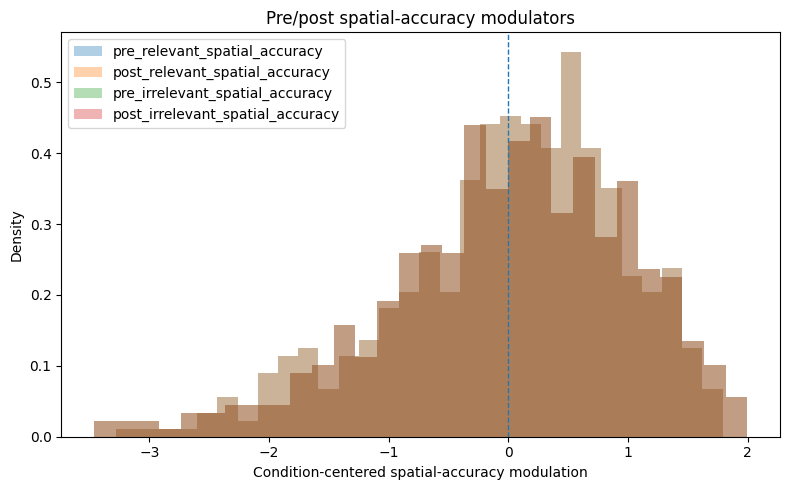

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/figures/pre_post_spatial_accuracy_modulator_distributions.png


,phase,trial_type,n_rows,mean_modulation,sd_modulation,min_modulation,max_modulation
0,post,post_irrelevant_spatial_accuracy,2922,-5.813283e-18,1.024424,-3.463459,1.996332
1,post,post_relevant_spatial_accuracy,3138,-6.722192e-18,0.951153,-3.276716,1.789849
2,pre,pre_irrelevant_spatial_accuracy,2922,-5.813283e-18,1.024424,-3.463459,1.996332
3,pre,pre_relevant_spatial_accuracy,3138,-6.722192e-18,0.951153,-3.276716,1.789849


In [14]:
# ============================================================
# 11. Plot pre/post spatial-accuracy modulator distributions
# ============================================================

parametric_events = all_pre_post_events.loc[
    all_pre_post_events["row_role"] == "parametric_modulator"
].copy()

fig, ax = plt.subplots(figsize=(8, 5))

for trial_type in [
    "pre_relevant_spatial_accuracy",
    "post_relevant_spatial_accuracy",
    "pre_irrelevant_spatial_accuracy",
    "post_irrelevant_spatial_accuracy",
]:
    values = parametric_events.loc[
        parametric_events["trial_type"] == trial_type,
        "modulation",
    ]
    
    if len(values) == 0:
        continue
    
    ax.hist(
        values,
        bins=30,
        density=True,
        alpha=0.35,
        label=trial_type,
    )

ax.axvline(0, linestyle="--", linewidth=1)
ax.set_xlabel("Condition-centered spatial-accuracy modulation")
ax.set_ylabel("Density")
ax.set_title("Pre/post spatial-accuracy modulators")
ax.legend()
plt.tight_layout()

out_path = FIG_DIR / "pre_post_spatial_accuracy_modulator_distributions.png"
fig.savefig(out_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

display(
    parametric_events
    .groupby(["phase", "trial_type"])
    .agg(
        n_rows=("modulation", "count"),
        mean_modulation=("modulation", "mean"),
        sd_modulation=("modulation", "std"),
        min_modulation=("modulation", "min"),
        max_modulation=("modulation", "max"),
    )
    .reset_index()
)

In [15]:
# ============================================================
# 12. First-level GLM setup
# Pre-post spatial-accuracy GLM
# ============================================================

from nilearn.glm.first_level import FirstLevelModel
from nilearn.interfaces.fmriprep import load_confounds
from nilearn.plotting import plot_design_matrix
from nilearn.image import load_img
import warnings

SMOOTHING_FWHM = 5.0
SMOOTHING_LABEL = "smoothed5mm"

FIRST_LEVEL_DIR = OUT_DIR / f"first_level_{SMOOTHING_LABEL}"
FIRST_LEVEL_MAPS_DIR = FIRST_LEVEL_DIR / "maps"
FIRST_LEVEL_DESIGN_DIR = FIRST_LEVEL_DIR / "design_matrices"
FIRST_LEVEL_FIG_DIR = FIRST_LEVEL_DIR / "figures"

for path in [
    FIRST_LEVEL_DIR,
    FIRST_LEVEL_MAPS_DIR,
    FIRST_LEVEL_DESIGN_DIR,
    FIRST_LEVEL_FIG_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

print("First-level output directory:")
print(FIRST_LEVEL_DIR)


def get_pre_post_events_path(subject):
    return (
        EVENTS_DIR
        / f"{subject}_task-{VIEWING_TASK}_pre_post_events_spatial_accuracy.tsv"
    )


def get_bold_file(subject, session, run=VIEWING_RUN, space=BOLD_SPACE):
    return (
        FMRIPREP_DIR
        / subject
        / session
        / "func"
        / f"{subject}_{session}_task-{VIEWING_TASK}_run-{run}_space-{space}_desc-preproc_bold.nii.gz"
    )


def get_first_level_z_map_path(subject, contrast_name):
    return (
        FIRST_LEVEL_MAPS_DIR
        / f"{subject}_{contrast_name}_{SMOOTHING_LABEL}_zmap.nii.gz"
    )


def get_first_level_effect_map_path(subject, contrast_name):
    return (
        FIRST_LEVEL_MAPS_DIR
        / f"{subject}_{contrast_name}_{SMOOTHING_LABEL}_effect.nii.gz"
    )


def infer_tr_from_bold(bold_path):
    img = nib.load(str(bold_path))
    return float(img.header.get_zooms()[3])


print("Setup complete.")

First-level output directory:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/first_level_smoothed5mm
Setup complete.


In [16]:
# ============================================================
# 13. Load pre/post events separately for first-level model
# ============================================================

def load_pre_post_events_for_glm(subject):
    events_path = get_pre_post_events_path(subject)
    assert events_path.exists(), f"Missing events file: {events_path}"
    
    events = pd.read_csv(events_path, sep="\t")
    
    required_cols = ["onset", "duration", "trial_type", "modulation", "phase"]
    missing = [col for col in required_cols if col not in events.columns]
    assert len(missing) == 0, f"{subject}: missing columns {missing}"
    
    pre_events = events.loc[
        events["phase"] == "pre",
        ["onset", "duration", "trial_type", "modulation"]
    ].copy()
    
    post_events = events.loc[
        events["phase"] == "post",
        ["onset", "duration", "trial_type", "modulation"]
    ].copy()
    
    # Sanity checks
    assert len(pre_events) > 0
    assert len(post_events) > 0
    
    return pre_events, post_events


# Quick test
test_subject = pre_post_subjects[0]
test_pre_events, test_post_events = load_pre_post_events_for_glm(test_subject)

print("Test subject:", test_subject)
print("Pre events shape:", test_pre_events.shape)
print("Post events shape:", test_post_events.shape)

print("\nPre trial types:")
display(test_pre_events["trial_type"].value_counts().rename_axis("trial_type").reset_index(name="n"))

print("\nPost trial types:")
display(test_post_events["trial_type"].value_counts().rename_axis("trial_type").reset_index(name="n"))

Test subject: sub-P10
Pre events shape: (552, 4)
Post events shape: (552, 4)

Pre trial types:


,trial_type,n
0,pre_other_no_spatial_accuracy,216
1,pre_relevant_spatial_accuracy,96
2,pre_relevant_valid_main,96
3,pre_irrelevant_spatial_accuracy,72
4,pre_irrelevant_valid_main,72



Post trial types:


,trial_type,n
0,post_other_no_spatial_accuracy,216
1,post_relevant_spatial_accuracy,96
2,post_relevant_valid_main,96
3,post_irrelevant_spatial_accuracy,72
4,post_irrelevant_valid_main,72


In [17]:
# ============================================================
# 14. Load fMRIPrep confounds for pre and post runs
# ============================================================

def load_basic_confounds_for_bold(bold_path):
    """
    Match previous GLM notebooks:
    motion full + wm/csf basic + high-pass.
    """
    confounds, sample_mask = load_confounds(
        str(bold_path),
        strategy=["motion", "wm_csf", "high_pass"],
        motion="full",
        wm_csf="basic",
    )
    
    # Make sure all columns are numeric and finite enough for nilearn.
    confounds = confounds.copy()
    confounds = confounds.replace([np.inf, -np.inf], np.nan)
    confounds = confounds.fillna(0.0)
    
    return confounds, sample_mask


# Quick test
test_pre_bold = get_bold_file(test_subject, PRE_SESSION)
test_post_bold = get_bold_file(test_subject, POST_SESSION)

test_pre_confounds, test_pre_sample_mask = load_basic_confounds_for_bold(test_pre_bold)
test_post_confounds, test_post_sample_mask = load_basic_confounds_for_bold(test_post_bold)

print("Test subject:", test_subject)
print("Pre BOLD:", test_pre_bold)
print("Post BOLD:", test_post_bold)
print("Pre confounds shape:", test_pre_confounds.shape)
print("Post confounds shape:", test_post_confounds.shape)
print("Pre sample mask:", None if test_pre_sample_mask is None else len(test_pre_sample_mask))
print("Post sample mask:", None if test_post_sample_mask is None else len(test_post_sample_mask))

display(test_pre_confounds.head())

Test subject: sub-P10
Pre BOLD: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P10/ses-01/func/sub-P10_ses-01_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz
Post BOLD: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/fmriprep_output/sub-P10/ses-05/func/sub-P10_ses-05_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz
Pre confounds shape: (2026, 66)
Post confounds shape: (1994, 65)
Pre sample mask: None
Post sample mask: None


,cosine00,cosine01,cosine02,cosine03,cosine04,cosine05,cosine06,cosine07,cosine08,cosine09,...,trans_x_power2,trans_y,trans_y_derivative1,trans_y_derivative1_power2,trans_y_power2,trans_z,trans_z_derivative1,trans_z_derivative1_power2,trans_z_power2,white_matter
0,0.031419,0.031419,0.031419,0.031419,0.031419,0.031419,0.031419,0.031419,0.031418,0.031418,...,-0.144673,-0.153337,0.003689,-0.000990,-0.037603,-0.633525,0.028163,-0.001625,-0.265171,-10.269941
1,0.031419,0.031419,0.031418,0.031418,0.031417,0.031416,0.031415,0.031414,0.031412,0.031411,...,-0.142835,-0.149554,0.003689,-0.000990,-0.037667,-0.604638,0.028163,-0.001625,-0.275335,-10.463841
2,0.031419,0.031418,0.031417,0.031415,0.031413,0.031411,0.031408,0.031404,0.031400,0.031396,...,-0.142835,-0.143197,0.006263,-0.000963,-0.037712,-0.602123,0.001791,-0.002453,-0.276141,-10.919850
3,0.031419,0.031417,0.031415,0.031412,0.031408,0.031403,0.031397,0.031390,0.031382,0.031373,...,-0.143157,-0.162059,-0.018956,-0.000648,-0.037344,-0.584127,0.017272,-0.002136,-0.281538,-10.132609
4,0.031418,0.031416,0.031412,0.031407,0.031400,0.031392,0.031382,0.031370,0.031357,0.031343,...,-0.142835,-0.164877,-0.002912,-0.000996,-0.037228,-0.589037,-0.005634,-0.002436,-0.280130,-10.616490


[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.


/tmp/ipykernel_2639888/1963326568.py:82: UserWarning: Contrast for run 0 is null.
  z_map = model.compute_contrast(
/tmp/ipykernel_2639888/1963326568.py:87: UserWarning: Contrast for run 0 is null.
  effect_map = model.compute_contrast(
/tmp/ipykernel_2639888/1963326568.py:82: UserWarning: Contrast for run 1 is null.
  z_map = model.compute_contrast(
/tmp/ipykernel_2639888/1963326568.py:87: UserWarning: Contrast for run 1 is null.
  effect_map = model.compute_contrast(
/tmp/ipykernel_2639888/1963326568.py:123: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


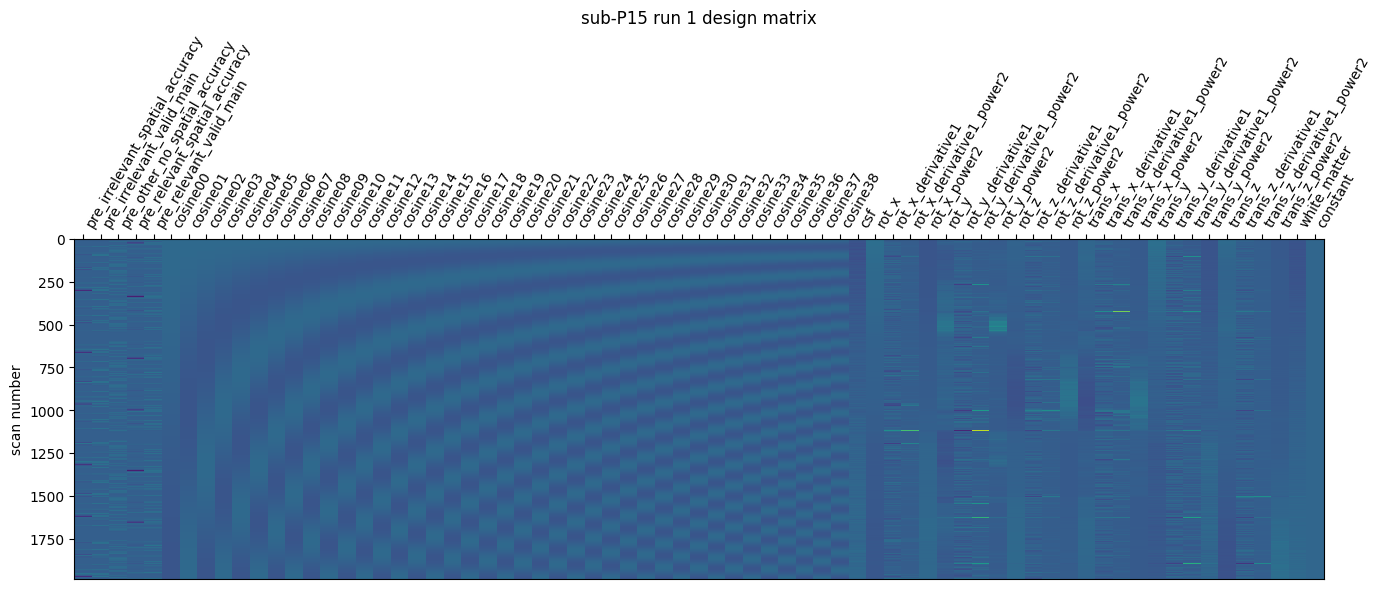

/tmp/ipykernel_2639888/1963326568.py:123: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


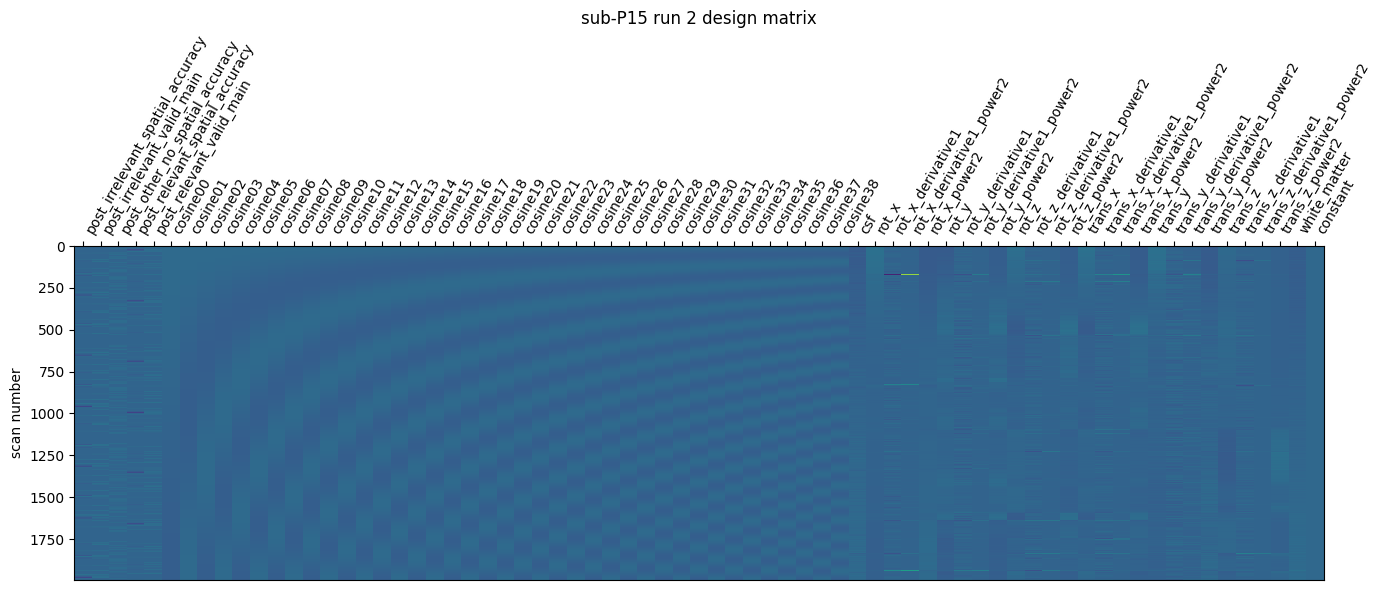

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/first_level_smoothed5mm/figures/sub-P15_run-2_design_matrix_smoothed5mm.png
Subject QC:


,subject,tr,n_pre_scans,n_post_scans,n_pre_events,n_post_events,n_design_columns_run_1,n_design_columns_run_2,design_columns_run_1,design_columns_run_2
0,sub-P15,1.3,1986,1995,594,594,71,71,pre_irrelevant_spatial_accuracy;pre_irrelevant...,post_irrelevant_spatial_accuracy;post_irreleva...



Contrast QC:


,subject,contrast,n_runs,missing_regressors_run_1,missing_regressors_run_2,z_map_saved,effect_map_saved
0,sub-P15,post_gt_pre_spatial_accuracy,2,"post_relevant_spatial_accuracy,post_irrelevant...","pre_relevant_spatial_accuracy,pre_irrelevant_s...",True,True
1,sub-P15,post_gt_pre_relevant_spatial_accuracy,2,post_relevant_spatial_accuracy,pre_relevant_spatial_accuracy,True,True
2,sub-P15,post_gt_pre_irrelevant_spatial_accuracy,2,post_irrelevant_spatial_accuracy,pre_irrelevant_spatial_accuracy,True,True
3,sub-P15,relevant_gt_irrelevant_post_gt_pre_spatial_acc...,2,"post_relevant_spatial_accuracy,post_irrelevant...","pre_relevant_spatial_accuracy,pre_irrelevant_s...",True,True
4,sub-P15,post_spatial_accuracy_positive,2,"post_relevant_spatial_accuracy,post_irrelevant...",,True,True
5,sub-P15,pre_spatial_accuracy_positive,2,,"pre_relevant_spatial_accuracy,pre_irrelevant_s...",True,True



Design columns run 1:
['pre_irrelevant_spatial_accuracy', 'pre_irrelevant_valid_main', 'pre_other_no_spatial_accuracy', 'pre_relevant_spatial_accuracy', 'pre_relevant_valid_main', 'cosine00', 'cosine01', 'cosine02', 'cosine03', 'cosine04', 'cosine05', 'cosine06', 'cosine07', 'cosine08', 'cosine09', 'cosine10', 'cosine11', 'cosine12', 'cosine13', 'cosine14', 'cosine15', 'cosine16', 'cosine17', 'cosine18', 'cosine19', 'cosine20', 'cosine21', 'cosine22', 'cosine23', 'cosine24', 'cosine25', 'cosine26', 'cosine27', 'cosine28', 'cosine29', 'cosine30', 'cosine31', 'cosine32', 'cosine33', 'cosine34', 'cosine35', 'cosine36', 'cosine37', 'cosine38', 'csf', 'rot_x', 'rot_x_derivative1', 'rot_x_derivative1_power2', 'rot_x_power2', 'rot_y', 'rot_y_derivative1', 'rot_y_derivative1_power2', 'rot_y_power2', 'rot_z', 'rot_z_derivative1', 'rot_z_derivative1_power2', 'rot_z_power2', 'trans_x', 'trans_x_derivative1', 'trans_x_derivative1_power2', 'trans_x_power2', 'trans_y', 'trans_y_derivative1', 'trans

In [19]:
# ============================================================
# 15. Fit one subject first-level GLM as sanity check
# ============================================================

def build_contrast_vector_from_design(design_columns, contrast_weights):
    contrast_vector = np.zeros(len(design_columns))
    
    missing_regressors = []
    
    for regressor_name, weight in contrast_weights.items():
        if regressor_name in design_columns:
            idx = list(design_columns).index(regressor_name)
            contrast_vector[idx] = weight
        else:
            missing_regressors.append(regressor_name)
    
    return contrast_vector, missing_regressors


def fit_pre_post_first_level_subject(subject, save_outputs=True, make_design_plot=False):
    pre_bold = get_bold_file(subject, PRE_SESSION)
    post_bold = get_bold_file(subject, POST_SESSION)
    
    assert pre_bold.exists(), f"Missing pre BOLD: {pre_bold}"
    assert post_bold.exists(), f"Missing post BOLD: {post_bold}"
    
    pre_events, post_events = load_pre_post_events_for_glm(subject)
    
    pre_confounds, pre_sample_mask = load_basic_confounds_for_bold(pre_bold)
    post_confounds, post_sample_mask = load_basic_confounds_for_bold(post_bold)
    
    tr_pre = infer_tr_from_bold(pre_bold)
    tr_post = infer_tr_from_bold(post_bold)
    
    assert np.isclose(tr_pre, tr_post), f"{subject}: pre/post TR mismatch: {tr_pre}, {tr_post}"
    tr = tr_pre
    
    model = FirstLevelModel(
        t_r=tr,
        hrf_model="spm",
        drift_model=None,  # high-pass regressors already loaded from fMRIPrep
        noise_model="ar1",
        standardize=False,
        signal_scaling=0,
        smoothing_fwhm=SMOOTHING_FWHM,
        minimize_memory=False,
    )
    
    if pre_sample_mask is None and post_sample_mask is None:
        sample_masks_for_fit = None
    else:
        sample_masks_for_fit = [pre_sample_mask, post_sample_mask]
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model = model.fit(
            run_imgs=[str(pre_bold), str(post_bold)],
            events=[pre_events, post_events],
            confounds=[pre_confounds, post_confounds],
            sample_masks=sample_masks_for_fit,
        )
    
    # Nilearn creates one design matrix per run.
    design_matrices = model.design_matrices_
    
    # For multi-run models, compute_contrast can accept one vector per run.
    # Here we build the same conceptual contrast for both design matrices.
    contrast_qc_rows = []
    
    for contrast_name, weights in PRE_POST_SPATIAL_CONTRASTS.items():
        run_contrast_vectors = []
        missing_by_run = []
        
        for run_idx, design_matrix in enumerate(design_matrices):
            contrast_vector, missing = build_contrast_vector_from_design(
                design_matrix.columns,
                weights,
            )
            run_contrast_vectors.append(contrast_vector)
            missing_by_run.append(missing)
        
        z_map = model.compute_contrast(
            run_contrast_vectors,
            output_type="z_score",
        )
        
        effect_map = model.compute_contrast(
            run_contrast_vectors,
            output_type="effect_size",
        )
        
        if save_outputs:
            z_path = get_first_level_z_map_path(subject, contrast_name)
            effect_path = get_first_level_effect_map_path(subject, contrast_name)
            
            z_map.to_filename(str(z_path))
            effect_map.to_filename(str(effect_path))
        
        contrast_qc_rows.append({
            "subject": subject,
            "contrast": contrast_name,
            "n_runs": len(design_matrices),
            "missing_regressors_run_1": ",".join(missing_by_run[0]),
            "missing_regressors_run_2": ",".join(missing_by_run[1]),
            "z_map_saved": save_outputs,
            "effect_map_saved": save_outputs,
        })
    
    if save_outputs:
        for run_idx, design_matrix in enumerate(design_matrices, start=1):
            design_path = (
                FIRST_LEVEL_DESIGN_DIR
                / f"{subject}_run-{run_idx}_design_matrix_{SMOOTHING_LABEL}.csv"
            )
            design_matrix.to_csv(design_path)
            
            if make_design_plot:
                plot_design_matrix(design_matrix)
                fig = plt.gcf()
                fig.set_size_inches(14, 6)
                
                plt.title(f"{subject} run {run_idx} design matrix")
                plt.tight_layout()
                
                fig_path = (
                    FIRST_LEVEL_FIG_DIR
                    / f"{subject}_run-{run_idx}_design_matrix_{SMOOTHING_LABEL}.png"
                )
                fig.savefig(fig_path, dpi=200, bbox_inches="tight")
                plt.show()
    
    print("Saved:", fig_path)
    
    subject_qc = {
        "subject": subject,
        "tr": tr,
        "n_pre_scans": nib.load(str(pre_bold)).shape[-1],
        "n_post_scans": nib.load(str(post_bold)).shape[-1],
        "n_pre_events": len(pre_events),
        "n_post_events": len(post_events),
        "n_design_columns_run_1": design_matrices[0].shape[1],
        "n_design_columns_run_2": design_matrices[1].shape[1],
        "design_columns_run_1": ";".join(design_matrices[0].columns),
        "design_columns_run_2": ";".join(design_matrices[1].columns),
    }
    
    return model, pd.DataFrame(contrast_qc_rows), subject_qc


test_subject = "sub-P15"

model_test, contrast_qc_test, subject_qc_test = fit_pre_post_first_level_subject(
    test_subject,
    save_outputs=True,
    make_design_plot=True,
)

print("Subject QC:")
display(pd.DataFrame([subject_qc_test]))

print("\nContrast QC:")
display(contrast_qc_test)

print("\nDesign columns run 1:")
print(model_test.design_matrices_[0].columns.tolist())

print("\nDesign columns run 2:")
print(model_test.design_matrices_[1].columns.tolist())

In [21]:
# ============================================================
# 17. Run first-level GLM for all pre-post subjects
# Clean N=27 sample, excluding sub-P37
# Includes corrected first-level function
# ============================================================

def build_contrast_vector_from_design(design_columns, contrast_weights):
    contrast_vector = np.zeros(len(design_columns))
    
    missing_regressors = []
    
    for regressor_name, weight in contrast_weights.items():
        if regressor_name in design_columns:
            idx = list(design_columns).index(regressor_name)
            contrast_vector[idx] = weight
        else:
            missing_regressors.append(regressor_name)
    
    return contrast_vector, missing_regressors


def fit_pre_post_first_level_subject(subject, save_outputs=True, make_design_plot=False):
    pre_bold = get_bold_file(subject, PRE_SESSION)
    post_bold = get_bold_file(subject, POST_SESSION)
    
    assert pre_bold.exists(), f"Missing pre BOLD: {pre_bold}"
    assert post_bold.exists(), f"Missing post BOLD: {post_bold}"
    
    pre_events, post_events = load_pre_post_events_for_glm(subject)
    
    pre_confounds, pre_sample_mask = load_basic_confounds_for_bold(pre_bold)
    post_confounds, post_sample_mask = load_basic_confounds_for_bold(post_bold)
    
    tr_pre = infer_tr_from_bold(pre_bold)
    tr_post = infer_tr_from_bold(post_bold)
    
    assert np.isclose(tr_pre, tr_post), (
        f"{subject}: pre/post TR mismatch: {tr_pre}, {tr_post}"
    )
    
    tr = tr_pre
    
    model = FirstLevelModel(
        t_r=tr,
        hrf_model="spm",
        drift_model=None,  # high-pass regressors already loaded from fMRIPrep
        noise_model="ar1",
        standardize=False,
        signal_scaling=0,
        smoothing_fwhm=SMOOTHING_FWHM,
        minimize_memory=False,
    )
    
    # Nilearn does not accept sample_masks=[None, None].
    if pre_sample_mask is None and post_sample_mask is None:
        sample_masks_for_fit = None
    else:
        sample_masks_for_fit = [pre_sample_mask, post_sample_mask]
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model = model.fit(
            run_imgs=[str(pre_bold), str(post_bold)],
            events=[pre_events, post_events],
            confounds=[pre_confounds, post_confounds],
            sample_masks=sample_masks_for_fit,
        )
    
    design_matrices = model.design_matrices_
    
    contrast_qc_rows = []
    
    for contrast_name, weights in PRE_POST_SPATIAL_CONTRASTS.items():
        run_contrast_vectors = []
        missing_by_run = []
        is_null_by_run = []
        
        for run_idx, design_matrix in enumerate(design_matrices):
            contrast_vector, missing = build_contrast_vector_from_design(
                design_matrix.columns,
                weights,
            )
            
            run_contrast_vectors.append(contrast_vector)
            missing_by_run.append(missing)
            is_null_by_run.append(bool(np.allclose(contrast_vector, 0)))
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            
            z_map = model.compute_contrast(
                run_contrast_vectors,
                output_type="z_score",
            )
            
            effect_map = model.compute_contrast(
                run_contrast_vectors,
                output_type="effect_size",
            )
        
        if save_outputs:
            z_path = get_first_level_z_map_path(subject, contrast_name)
            effect_path = get_first_level_effect_map_path(subject, contrast_name)
            
            z_map.to_filename(str(z_path))
            effect_map.to_filename(str(effect_path))
        else:
            z_path = None
            effect_path = None
        
        contrast_qc_rows.append({
            "subject": subject,
            "contrast": contrast_name,
            "n_runs": len(design_matrices),
            "missing_regressors_run_1": ",".join(missing_by_run[0]),
            "missing_regressors_run_2": ",".join(missing_by_run[1]),
            "null_contrast_run_1": is_null_by_run[0],
            "null_contrast_run_2": is_null_by_run[1],
            "z_map_saved": save_outputs,
            "effect_map_saved": save_outputs,
            "z_map_path": str(z_path) if z_path is not None else "",
            "effect_map_path": str(effect_path) if effect_path is not None else "",
        })
    
    if save_outputs:
        for run_idx, design_matrix in enumerate(design_matrices, start=1):
            design_path = (
                FIRST_LEVEL_DESIGN_DIR
                / f"{subject}_run-{run_idx}_design_matrix_{SMOOTHING_LABEL}.csv"
            )
            
            design_matrix.to_csv(design_path)
            
            if make_design_plot:
                plot_design_matrix(design_matrix)
                fig = plt.gcf()
                fig.set_size_inches(14, 6)
                
                plt.title(f"{subject} run {run_idx} design matrix")
                plt.tight_layout()
                
                fig_path = (
                    FIRST_LEVEL_FIG_DIR
                    / f"{subject}_run-{run_idx}_design_matrix_{SMOOTHING_LABEL}.png"
                )
                
                fig.savefig(fig_path, dpi=200, bbox_inches="tight")
                plt.show()
                
                print("Saved design figure:", fig_path)
    
    subject_qc = {
        "subject": subject,
        "tr": tr,
        "n_pre_scans": nib.load(str(pre_bold)).shape[-1],
        "n_post_scans": nib.load(str(post_bold)).shape[-1],
        "n_pre_events": len(pre_events),
        "n_post_events": len(post_events),
        "n_design_columns_run_1": design_matrices[0].shape[1],
        "n_design_columns_run_2": design_matrices[1].shape[1],
        "design_columns_run_1": ";".join(design_matrices[0].columns),
        "design_columns_run_2": ";".join(design_matrices[1].columns),
    }
    
    return model, pd.DataFrame(contrast_qc_rows), subject_qc


# ------------------------------------------------------------
# Run all subjects
# ------------------------------------------------------------

all_first_level_qc_rows = []
all_contrast_qc_rows = []

failed_subjects = []

for subject in pre_post_subjects:
    print("\n" + "=" * 80)
    print("Running first-level pre-post GLM:", subject)
    
    try:
        model, contrast_qc, subject_qc = fit_pre_post_first_level_subject(
            subject,
            save_outputs=True,
            make_design_plot=False,
        )
        
        all_first_level_qc_rows.append(subject_qc)
        all_contrast_qc_rows.append(contrast_qc)
        
        print("Finished:", subject)
        
    except Exception as e:
        print("FAILED:", subject)
        print(type(e).__name__, e)
        
        failed_subjects.append({
            "subject": subject,
            "error_type": type(e).__name__,
            "error_message": str(e),
        })

first_level_qc = pd.DataFrame(all_first_level_qc_rows)

if len(all_contrast_qc_rows) > 0:
    first_level_contrast_qc = pd.concat(all_contrast_qc_rows, ignore_index=True)
else:
    first_level_contrast_qc = pd.DataFrame()

failed_subjects_df = pd.DataFrame(failed_subjects)

print("\nFirst-level QC:")
display(first_level_qc)

print("\nContrast QC:")
display(first_level_contrast_qc)

print("\nFailed subjects:")
display(failed_subjects_df)

first_level_qc_path = TABLE_DIR / f"pre_post_first_level_qc_{SMOOTHING_LABEL}.csv"
contrast_qc_path = TABLE_DIR / f"pre_post_first_level_contrast_qc_{SMOOTHING_LABEL}.csv"
failed_subjects_path = TABLE_DIR / f"pre_post_first_level_failed_subjects_{SMOOTHING_LABEL}.csv"

first_level_qc.to_csv(first_level_qc_path, index=False)
first_level_contrast_qc.to_csv(contrast_qc_path, index=False)
failed_subjects_df.to_csv(failed_subjects_path, index=False)

print("\nSaved:")
print(first_level_qc_path)
print(contrast_qc_path)
print(failed_subjects_path)

assert len(failed_subjects_df) == 0, "Some subjects failed. Inspect failed_subjects_df."
assert len(first_level_qc) == len(pre_post_subjects), "Unexpected number of successful subjects."


Running first-level pre-post GLM: sub-P10
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Finished: sub-P10

Running first-level pre-post GLM: sub-P12
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Finished: sub-P12

Running first-level pre-post GLM: sub-P13
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Finished: sub-P13

Running first-level pre-post GLM: sub-P14
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Finished: sub-P14

Running first-level

,subject,tr,n_pre_scans,n_post_scans,n_pre_events,n_post_events,n_design_columns_run_1,n_design_columns_run_2,design_columns_run_1,design_columns_run_2
0,sub-P10,1.3,2026,1994,552,552,72,71,pre_irrelevant_spatial_accuracy;pre_irrelevant...,post_irrelevant_spatial_accuracy;post_irreleva...
1,sub-P12,1.3,1996,1954,564,564,71,70,pre_irrelevant_spatial_accuracy;pre_irrelevant...,post_irrelevant_spatial_accuracy;post_irreleva...
2,sub-P13,1.3,1952,1957,636,636,70,70,pre_irrelevant_spatial_accuracy;pre_irrelevant...,post_irrelevant_spatial_accuracy;post_irreleva...
3,sub-P14,1.3,1967,1922,666,666,70,70,pre_irrelevant_spatial_accuracy;pre_irrelevant...,post_irrelevant_spatial_accuracy;post_irreleva...
4,sub-P15,1.3,1986,1995,594,594,71,71,pre_irrelevant_spatial_accuracy;pre_irrelevant...,post_irrelevant_spatial_accuracy;post_irreleva...
5,sub-P16,1.3,2024,1955,624,624,72,70,pre_irrelevant_spatial_accuracy;pre_irrelevant...,post_irrelevant_spatial_accuracy;post_irreleva...
6,sub-P17,1.3,1906,1946,570,570,69,70,pre_irrelevant_spatial_accuracy;pre_irrelevant...,post_irrelevant_spatial_accuracy;post_irreleva...
7,sub-P18,1.3,1979,1993,642,642,71,71,pre_irrelevant_spatial_accuracy;pre_irrelevant...,post_irrelevant_spatial_accuracy;post_irreleva...
8,sub-P19,1.3,1939,1945,594,594,70,70,pre_irrelevant_spatial_accuracy;pre_irrelevant...,post_irrelevant_spatial_accuracy;post_irreleva...
9,sub-P21,1.3,1956,1961,588,588,70,70,pre_irrelevant_spatial_accuracy;pre_irrelevant...,post_irrelevant_spatial_accuracy;post_irreleva...



Contrast QC:


,subject,contrast,n_runs,missing_regressors_run_1,missing_regressors_run_2,null_contrast_run_1,null_contrast_run_2,z_map_saved,effect_map_saved,z_map_path,effect_map_path
0,sub-P10,post_gt_pre_spatial_accuracy,2,"post_relevant_spatial_accuracy,post_irrelevant...","pre_relevant_spatial_accuracy,pre_irrelevant_s...",False,False,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
1,sub-P10,post_gt_pre_relevant_spatial_accuracy,2,post_relevant_spatial_accuracy,pre_relevant_spatial_accuracy,False,False,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
2,sub-P10,post_gt_pre_irrelevant_spatial_accuracy,2,post_irrelevant_spatial_accuracy,pre_irrelevant_spatial_accuracy,False,False,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
3,sub-P10,relevant_gt_irrelevant_post_gt_pre_spatial_acc...,2,"post_relevant_spatial_accuracy,post_irrelevant...","pre_relevant_spatial_accuracy,pre_irrelevant_s...",False,False,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
4,sub-P10,post_spatial_accuracy_positive,2,"post_relevant_spatial_accuracy,post_irrelevant...",,True,False,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
...,...,...,...,...,...,...,...,...,...,...,...
133,sub-P51,post_gt_pre_relevant_spatial_accuracy,2,post_relevant_spatial_accuracy,pre_relevant_spatial_accuracy,False,False,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
134,sub-P51,post_gt_pre_irrelevant_spatial_accuracy,2,post_irrelevant_spatial_accuracy,pre_irrelevant_spatial_accuracy,False,False,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
135,sub-P51,relevant_gt_irrelevant_post_gt_pre_spatial_acc...,2,"post_relevant_spatial_accuracy,post_irrelevant...","pre_relevant_spatial_accuracy,pre_irrelevant_s...",False,False,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
136,sub-P51,post_spatial_accuracy_positive,2,"post_relevant_spatial_accuracy,post_irrelevant...",,True,False,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...



Failed subjects:


,subject,error_type,error_message
0,sub-P22,TypeError,'NoneType' object is not iterable
1,sub-P43,TypeError,'NoneType' object is not iterable
2,sub-P44,TypeError,'NoneType' object is not iterable
3,sub-P50,TypeError,'NoneType' object is not iterable



Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/tables/pre_post_first_level_qc_smoothed5mm.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/tables/pre_post_first_level_contrast_qc_smoothed5mm.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/tables/pre_post_first_level_failed_subjects_smoothed5mm.csv


AssertionError: Some subjects failed. Inspect failed_subjects_df.

In [22]:
# ============================================================
# 17b. Rerun only failed first-level subjects
# Fix mixed sample-mask issue: [None, array] is invalid in Nilearn
# ============================================================

failed_subjects_to_rerun = ["sub-P22", "sub-P43", "sub-P44", "sub-P50"]

print("Subjects to rerun:")
print(failed_subjects_to_rerun)

assert all(subject in pre_post_subjects for subject in failed_subjects_to_rerun)


def fit_pre_post_first_level_subject(subject, save_outputs=True, make_design_plot=False):
    pre_bold = get_bold_file(subject, PRE_SESSION)
    post_bold = get_bold_file(subject, POST_SESSION)
    
    assert pre_bold.exists(), f"Missing pre BOLD: {pre_bold}"
    assert post_bold.exists(), f"Missing post BOLD: {post_bold}"
    
    pre_events, post_events = load_pre_post_events_for_glm(subject)
    
    pre_confounds, pre_sample_mask = load_basic_confounds_for_bold(pre_bold)
    post_confounds, post_sample_mask = load_basic_confounds_for_bold(post_bold)
    
    tr_pre = infer_tr_from_bold(pre_bold)
    tr_post = infer_tr_from_bold(post_bold)
    
    assert np.isclose(tr_pre, tr_post), (
        f"{subject}: pre/post TR mismatch: {tr_pre}, {tr_post}"
    )
    
    tr = tr_pre
    
    model = FirstLevelModel(
        t_r=tr,
        hrf_model="spm",
        drift_model=None,
        noise_model="ar1",
        standardize=False,
        signal_scaling=0,
        smoothing_fwhm=SMOOTHING_FWHM,
        minimize_memory=False,
    )
    
    # ------------------------------------------------------------
    # Robust sample-mask handling
    # ------------------------------------------------------------
    # Nilearn accepts:
    # - sample_masks=None if no run has a sample mask
    # - [array, array] if runs have masks
    #
    # It does NOT accept [None, array].
    # Therefore, replace None with a full index vector when needed.
    n_pre_scans = nib.load(str(pre_bold)).shape[-1]
    n_post_scans = nib.load(str(post_bold)).shape[-1]
    
    original_pre_sample_mask_is_none = pre_sample_mask is None
    original_post_sample_mask_is_none = post_sample_mask is None
    
    if pre_sample_mask is None and post_sample_mask is None:
        sample_masks_for_fit = None
    else:
        if pre_sample_mask is None:
            pre_sample_mask = np.arange(n_pre_scans, dtype=int)
        
        if post_sample_mask is None:
            post_sample_mask = np.arange(n_post_scans, dtype=int)
        
        sample_masks_for_fit = [pre_sample_mask, post_sample_mask]
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model = model.fit(
            run_imgs=[str(pre_bold), str(post_bold)],
            events=[pre_events, post_events],
            confounds=[pre_confounds, post_confounds],
            sample_masks=sample_masks_for_fit,
        )
    
    design_matrices = model.design_matrices_
    
    contrast_qc_rows = []
    
    for contrast_name, weights in PRE_POST_SPATIAL_CONTRASTS.items():
        run_contrast_vectors = []
        missing_by_run = []
        is_null_by_run = []
        
        for run_idx, design_matrix in enumerate(design_matrices):
            contrast_vector, missing = build_contrast_vector_from_design(
                design_matrix.columns,
                weights,
            )
            
            run_contrast_vectors.append(contrast_vector)
            missing_by_run.append(missing)
            is_null_by_run.append(bool(np.allclose(contrast_vector, 0)))
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            
            z_map = model.compute_contrast(
                run_contrast_vectors,
                output_type="z_score",
            )
            
            effect_map = model.compute_contrast(
                run_contrast_vectors,
                output_type="effect_size",
            )
        
        if save_outputs:
            z_path = get_first_level_z_map_path(subject, contrast_name)
            effect_path = get_first_level_effect_map_path(subject, contrast_name)
            
            z_map.to_filename(str(z_path))
            effect_map.to_filename(str(effect_path))
        else:
            z_path = None
            effect_path = None
        
        contrast_qc_rows.append({
            "subject": subject,
            "contrast": contrast_name,
            "n_runs": len(design_matrices),
            "missing_regressors_run_1": ",".join(missing_by_run[0]),
            "missing_regressors_run_2": ",".join(missing_by_run[1]),
            "null_contrast_run_1": is_null_by_run[0],
            "null_contrast_run_2": is_null_by_run[1],
            "z_map_saved": save_outputs,
            "effect_map_saved": save_outputs,
            "z_map_path": str(z_path) if z_path is not None else "",
            "effect_map_path": str(effect_path) if effect_path is not None else "",
        })
    
    if save_outputs:
        for run_idx, design_matrix in enumerate(design_matrices, start=1):
            design_path = (
                FIRST_LEVEL_DESIGN_DIR
                / f"{subject}_run-{run_idx}_design_matrix_{SMOOTHING_LABEL}.csv"
            )
            
            design_matrix.to_csv(design_path)
            
            if make_design_plot:
                plot_design_matrix(design_matrix)
                fig = plt.gcf()
                fig.set_size_inches(14, 6)
                
                plt.title(f"{subject} run {run_idx} design matrix")
                plt.tight_layout()
                
                fig_path = (
                    FIRST_LEVEL_FIG_DIR
                    / f"{subject}_run-{run_idx}_design_matrix_{SMOOTHING_LABEL}.png"
                )
                
                fig.savefig(fig_path, dpi=200, bbox_inches="tight")
                plt.show()
                
                print("Saved design figure:", fig_path)
    
    subject_qc = {
        "subject": subject,
        "tr": tr,
        "n_pre_scans": n_pre_scans,
        "n_post_scans": n_post_scans,
        "n_pre_events": len(pre_events),
        "n_post_events": len(post_events),
        "n_pre_confounds": pre_confounds.shape[1],
        "n_post_confounds": post_confounds.shape[1],
        "pre_sample_mask_originally_none": original_pre_sample_mask_is_none,
        "post_sample_mask_originally_none": original_post_sample_mask_is_none,
        "pre_sample_mask_length": (
            np.nan if original_pre_sample_mask_is_none else len(pre_sample_mask)
        ),
        "post_sample_mask_length": (
            np.nan if original_post_sample_mask_is_none else len(post_sample_mask)
        ),
        "n_design_columns_run_1": design_matrices[0].shape[1],
        "n_design_columns_run_2": design_matrices[1].shape[1],
        "design_columns_run_1": ";".join(design_matrices[0].columns),
        "design_columns_run_2": ";".join(design_matrices[1].columns),
    }
    
    return model, pd.DataFrame(contrast_qc_rows), subject_qc


# ------------------------------------------------------------
# Rerun failed subjects only
# ------------------------------------------------------------

rerun_first_level_qc_rows = []
rerun_contrast_qc_rows = []
rerun_failed_subjects = []

for subject in failed_subjects_to_rerun:
    print("\n" + "=" * 80)
    print("Rerunning failed subject:", subject)
    
    try:
        model, contrast_qc, subject_qc = fit_pre_post_first_level_subject(
            subject,
            save_outputs=True,
            make_design_plot=False,
        )
        
        rerun_first_level_qc_rows.append(subject_qc)
        rerun_contrast_qc_rows.append(contrast_qc)
        
        print("Finished:", subject)
        
    except Exception as e:
        print("FAILED AGAIN:", subject)
        print(type(e).__name__, e)
        
        rerun_failed_subjects.append({
            "subject": subject,
            "error_type": type(e).__name__,
            "error_message": str(e),
        })

rerun_first_level_qc = pd.DataFrame(rerun_first_level_qc_rows)

if len(rerun_contrast_qc_rows) > 0:
    rerun_first_level_contrast_qc = pd.concat(rerun_contrast_qc_rows, ignore_index=True)
else:
    rerun_first_level_contrast_qc = pd.DataFrame()

rerun_failed_subjects_df = pd.DataFrame(rerun_failed_subjects)

print("\nRerun first-level QC:")
display(rerun_first_level_qc)

print("\nRerun contrast QC:")
display(rerun_first_level_contrast_qc)

print("\nRerun failed subjects:")
display(rerun_failed_subjects_df)


# ------------------------------------------------------------
# Combine previous successful QC with rerun QC
# ------------------------------------------------------------

previous_first_level_qc_path = TABLE_DIR / f"pre_post_first_level_qc_{SMOOTHING_LABEL}.csv"
previous_contrast_qc_path = TABLE_DIR / f"pre_post_first_level_contrast_qc_{SMOOTHING_LABEL}.csv"

previous_first_level_qc = pd.read_csv(previous_first_level_qc_path)
previous_contrast_qc = pd.read_csv(previous_contrast_qc_path)

# Remove old failed-subject rows if any somehow exist, then append rerun successes.
combined_first_level_qc = previous_first_level_qc.loc[
    ~previous_first_level_qc["subject"].isin(failed_subjects_to_rerun)
].copy()

combined_first_level_qc = pd.concat(
    [combined_first_level_qc, rerun_first_level_qc],
    ignore_index=True,
)

combined_contrast_qc = previous_contrast_qc.loc[
    ~previous_contrast_qc["subject"].isin(failed_subjects_to_rerun)
].copy()

combined_contrast_qc = pd.concat(
    [combined_contrast_qc, rerun_first_level_contrast_qc],
    ignore_index=True,
)

combined_first_level_qc = combined_first_level_qc.sort_values("subject").reset_index(drop=True)
combined_contrast_qc = combined_contrast_qc.sort_values(["subject", "contrast"]).reset_index(drop=True)

# New failed table after rerun.
final_failed_subjects_df = rerun_failed_subjects_df.copy()

combined_first_level_qc.to_csv(previous_first_level_qc_path, index=False)
combined_contrast_qc.to_csv(previous_contrast_qc_path, index=False)
final_failed_subjects_df.to_csv(
    TABLE_DIR / f"pre_post_first_level_failed_subjects_{SMOOTHING_LABEL}.csv",
    index=False,
)

print("\nCombined first-level QC:")
display(combined_first_level_qc)

print("\nCombined contrast QC:")
display(combined_contrast_qc)

print("\nFinal failed subjects:")
display(final_failed_subjects_df)

print("\nSaved updated QC tables:")
print(previous_first_level_qc_path)
print(previous_contrast_qc_path)

assert len(final_failed_subjects_df) == 0, "Some subjects still failed after rerun."
assert len(combined_first_level_qc) == len(pre_post_subjects), (
    "Unexpected number of successful subjects after rerun."
)

Subjects to rerun:
['sub-P22', 'sub-P43', 'sub-P44', 'sub-P50']

Rerunning failed subject: sub-P22
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Finished: sub-P22

Rerunning failed subject: sub-P43
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Finished: sub-P43

Rerunning failed subject: sub-P44
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Finished: sub-P44

Rerunning failed subject: sub-P50
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Finish

,subject,tr,n_pre_scans,n_post_scans,n_pre_events,n_post_events,n_pre_confounds,n_post_confounds,pre_sample_mask_originally_none,post_sample_mask_originally_none,pre_sample_mask_length,post_sample_mask_length,n_design_columns_run_1,n_design_columns_run_2,design_columns_run_1,design_columns_run_2
0,sub-P22,1.3,1977,2014,606,606,65,65,False,True,1976.0,NaN,71,71,pre_irrelevant_spatial_accuracy;pre_irrelevant...,post_irrelevant_spatial_accuracy;post_irreleva...
1,sub-P43,1.3,1736,1618,624,624,60,57,True,False,NaN,1617.0,66,63,pre_irrelevant_spatial_accuracy;pre_irrelevant...,post_irrelevant_spatial_accuracy;post_irreleva...
2,sub-P44,1.3,1669,1668,648,648,58,58,True,False,NaN,1667.0,64,64,pre_irrelevant_spatial_accuracy;pre_irrelevant...,post_irrelevant_spatial_accuracy;post_irreleva...
3,sub-P50,1.3,1692,1739,672,672,59,60,False,True,1690.0,NaN,65,66,pre_irrelevant_spatial_accuracy;pre_irrelevant...,post_irrelevant_spatial_accuracy;post_irreleva...



Rerun contrast QC:


,subject,contrast,n_runs,missing_regressors_run_1,missing_regressors_run_2,null_contrast_run_1,null_contrast_run_2,z_map_saved,effect_map_saved,z_map_path,effect_map_path
0,sub-P22,post_gt_pre_spatial_accuracy,2,"post_relevant_spatial_accuracy,post_irrelevant...","pre_relevant_spatial_accuracy,pre_irrelevant_s...",False,False,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
1,sub-P22,post_gt_pre_relevant_spatial_accuracy,2,post_relevant_spatial_accuracy,pre_relevant_spatial_accuracy,False,False,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
2,sub-P22,post_gt_pre_irrelevant_spatial_accuracy,2,post_irrelevant_spatial_accuracy,pre_irrelevant_spatial_accuracy,False,False,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
3,sub-P22,relevant_gt_irrelevant_post_gt_pre_spatial_acc...,2,"post_relevant_spatial_accuracy,post_irrelevant...","pre_relevant_spatial_accuracy,pre_irrelevant_s...",False,False,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
4,sub-P22,post_spatial_accuracy_positive,2,"post_relevant_spatial_accuracy,post_irrelevant...",,True,False,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
5,sub-P22,pre_spatial_accuracy_positive,2,,"pre_relevant_spatial_accuracy,pre_irrelevant_s...",False,True,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
6,sub-P43,post_gt_pre_spatial_accuracy,2,"post_relevant_spatial_accuracy,post_irrelevant...","pre_relevant_spatial_accuracy,pre_irrelevant_s...",False,False,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
7,sub-P43,post_gt_pre_relevant_spatial_accuracy,2,post_relevant_spatial_accuracy,pre_relevant_spatial_accuracy,False,False,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
8,sub-P43,post_gt_pre_irrelevant_spatial_accuracy,2,post_irrelevant_spatial_accuracy,pre_irrelevant_spatial_accuracy,False,False,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
9,sub-P43,relevant_gt_irrelevant_post_gt_pre_spatial_acc...,2,"post_relevant_spatial_accuracy,post_irrelevant...","pre_relevant_spatial_accuracy,pre_irrelevant_s...",False,False,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...



Rerun failed subjects:


""



Combined first-level QC:


,subject,tr,n_pre_scans,n_post_scans,n_pre_events,n_post_events,n_design_columns_run_1,n_design_columns_run_2,design_columns_run_1,design_columns_run_2,n_pre_confounds,n_post_confounds,pre_sample_mask_originally_none,post_sample_mask_originally_none,pre_sample_mask_length,post_sample_mask_length
0,sub-P10,1.3,2026,1994,552,552,72,71,pre_irrelevant_spatial_accuracy;pre_irrelevant...,post_irrelevant_spatial_accuracy;post_irreleva...,NaN,NaN,NaN,NaN,NaN,NaN
1,sub-P12,1.3,1996,1954,564,564,71,70,pre_irrelevant_spatial_accuracy;pre_irrelevant...,post_irrelevant_spatial_accuracy;post_irreleva...,NaN,NaN,NaN,NaN,NaN,NaN
2,sub-P13,1.3,1952,1957,636,636,70,70,pre_irrelevant_spatial_accuracy;pre_irrelevant...,post_irrelevant_spatial_accuracy;post_irreleva...,NaN,NaN,NaN,NaN,NaN,NaN
3,sub-P14,1.3,1967,1922,666,666,70,70,pre_irrelevant_spatial_accuracy;pre_irrelevant...,post_irrelevant_spatial_accuracy;post_irreleva...,NaN,NaN,NaN,NaN,NaN,NaN
4,sub-P15,1.3,1986,1995,594,594,71,71,pre_irrelevant_spatial_accuracy;pre_irrelevant...,post_irrelevant_spatial_accuracy;post_irreleva...,NaN,NaN,NaN,NaN,NaN,NaN
5,sub-P16,1.3,2024,1955,624,624,72,70,pre_irrelevant_spatial_accuracy;pre_irrelevant...,post_irrelevant_spatial_accuracy;post_irreleva...,NaN,NaN,NaN,NaN,NaN,NaN
6,sub-P17,1.3,1906,1946,570,570,69,70,pre_irrelevant_spatial_accuracy;pre_irrelevant...,post_irrelevant_spatial_accuracy;post_irreleva...,NaN,NaN,NaN,NaN,NaN,NaN
7,sub-P18,1.3,1979,1993,642,642,71,71,pre_irrelevant_spatial_accuracy;pre_irrelevant...,post_irrelevant_spatial_accuracy;post_irreleva...,NaN,NaN,NaN,NaN,NaN,NaN
8,sub-P19,1.3,1939,1945,594,594,70,70,pre_irrelevant_spatial_accuracy;pre_irrelevant...,post_irrelevant_spatial_accuracy;post_irreleva...,NaN,NaN,NaN,NaN,NaN,NaN
9,sub-P21,1.3,1956,1961,588,588,70,70,pre_irrelevant_spatial_accuracy;pre_irrelevant...,post_irrelevant_spatial_accuracy;post_irreleva...,NaN,NaN,NaN,NaN,NaN,NaN



Combined contrast QC:


,subject,contrast,n_runs,missing_regressors_run_1,missing_regressors_run_2,null_contrast_run_1,null_contrast_run_2,z_map_saved,effect_map_saved,z_map_path,effect_map_path
0,sub-P10,post_gt_pre_irrelevant_spatial_accuracy,2,post_irrelevant_spatial_accuracy,pre_irrelevant_spatial_accuracy,False,False,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
1,sub-P10,post_gt_pre_relevant_spatial_accuracy,2,post_relevant_spatial_accuracy,pre_relevant_spatial_accuracy,False,False,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
2,sub-P10,post_gt_pre_spatial_accuracy,2,"post_relevant_spatial_accuracy,post_irrelevant...","pre_relevant_spatial_accuracy,pre_irrelevant_s...",False,False,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
3,sub-P10,post_spatial_accuracy_positive,2,"post_relevant_spatial_accuracy,post_irrelevant...",NaN,True,False,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
4,sub-P10,pre_spatial_accuracy_positive,2,NaN,"pre_relevant_spatial_accuracy,pre_irrelevant_s...",False,True,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
...,...,...,...,...,...,...,...,...,...,...,...
157,sub-P51,post_gt_pre_relevant_spatial_accuracy,2,post_relevant_spatial_accuracy,pre_relevant_spatial_accuracy,False,False,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
158,sub-P51,post_gt_pre_spatial_accuracy,2,"post_relevant_spatial_accuracy,post_irrelevant...","pre_relevant_spatial_accuracy,pre_irrelevant_s...",False,False,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
159,sub-P51,post_spatial_accuracy_positive,2,"post_relevant_spatial_accuracy,post_irrelevant...",NaN,True,False,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
160,sub-P51,pre_spatial_accuracy_positive,2,NaN,"pre_relevant_spatial_accuracy,pre_irrelevant_s...",False,True,True,True,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...



Final failed subjects:


""



Saved updated QC tables:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/tables/pre_post_first_level_qc_smoothed5mm.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/tables/pre_post_first_level_contrast_qc_smoothed5mm.csv


In [23]:
# ============================================================
# 18. Check first-level map availability
# ============================================================

map_qc_rows = []

for contrast_name in PRE_POST_SPATIAL_CONTRASTS.keys():
    for subject in pre_post_subjects:
        z_path = get_first_level_z_map_path(subject, contrast_name)
        effect_path = get_first_level_effect_map_path(subject, contrast_name)
        
        map_qc_rows.append({
            "subject": subject,
            "contrast": contrast_name,
            "z_map_exists": z_path.exists(),
            "effect_map_exists": effect_path.exists(),
            "z_map_path": str(z_path),
            "effect_map_path": str(effect_path),
        })

first_level_map_qc = pd.DataFrame(map_qc_rows)

display(
    first_level_map_qc
    .groupby("contrast")
    .agg(
        n_subjects=("subject", "nunique"),
        n_z_maps=("z_map_exists", "sum"),
        n_effect_maps=("effect_map_exists", "sum"),
    )
    .reset_index()
)

missing_maps = first_level_map_qc.loc[
    (~first_level_map_qc["z_map_exists"])
    | (~first_level_map_qc["effect_map_exists"])
]

print("\nMissing maps:")
display(missing_maps)

map_qc_path = TABLE_DIR / f"pre_post_first_level_map_qc_{SMOOTHING_LABEL}.csv"
first_level_map_qc.to_csv(map_qc_path, index=False)

print("Saved:", map_qc_path)

assert missing_maps.empty, "Some first-level maps are missing."

,contrast,n_subjects,n_z_maps,n_effect_maps
0,post_gt_pre_irrelevant_spatial_accuracy,27,27,27
1,post_gt_pre_relevant_spatial_accuracy,27,27,27
2,post_gt_pre_spatial_accuracy,27,27,27
3,post_spatial_accuracy_positive,27,27,27
4,pre_spatial_accuracy_positive,27,27,27
5,relevant_gt_irrelevant_post_gt_pre_spatial_acc...,27,27,27



Missing maps:


,subject,contrast,z_map_exists,effect_map_exists,z_map_path,effect_map_path


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/tables/pre_post_first_level_map_qc_smoothed5mm.csv


In [24]:
# ============================================================
# 19. Second-level group GLM
# One-sample test across subjects using first-level effect maps
# ============================================================

from nilearn.glm.second_level import SecondLevelModel

SECOND_LEVEL_DIR = OUT_DIR / f"second_level_from_{SMOOTHING_LABEL}"
SECOND_LEVEL_MAPS_DIR = SECOND_LEVEL_DIR / "maps"
SECOND_LEVEL_FIG_DIR = SECOND_LEVEL_DIR / "figures"

for path in [
    SECOND_LEVEL_DIR,
    SECOND_LEVEL_MAPS_DIR,
    SECOND_LEVEL_FIG_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)


def get_group_z_map_path(contrast_name):
    return (
        SECOND_LEVEL_MAPS_DIR
        / f"group_pre_post_{contrast_name}_from_{SMOOTHING_LABEL}_zmap.nii.gz"
    )


def get_group_effect_map_path(contrast_name):
    return (
        SECOND_LEVEL_MAPS_DIR
        / f"group_pre_post_{contrast_name}_from_{SMOOTHING_LABEL}_effect.nii.gz"
    )


second_level_qc_rows = []

for contrast_name in PRE_POST_SPATIAL_CONTRASTS.keys():
    print("\n" + "=" * 80)
    print("Second-level contrast:", contrast_name)
    
    effect_maps = [
        str(get_first_level_effect_map_path(subject, contrast_name))
        for subject in pre_post_subjects
    ]
    
    assert all(Path(path).exists() for path in effect_maps), (
        f"Missing first-level effect map for {contrast_name}"
    )
    
    design_matrix = pd.DataFrame(
        np.ones((len(effect_maps), 1)),
        columns=["intercept"],
    )
    
    second_level_model = SecondLevelModel(
        smoothing_fwhm=None,
        minimize_memory=False,
    )
    
    second_level_model = second_level_model.fit(
        effect_maps,
        design_matrix=design_matrix,
    )
    
    group_z_map = second_level_model.compute_contrast(
        "intercept",
        output_type="z_score",
    )
    
    group_effect_map = second_level_model.compute_contrast(
        "intercept",
        output_type="effect_size",
    )
    
    z_path = get_group_z_map_path(contrast_name)
    effect_path = get_group_effect_map_path(contrast_name)
    
    group_z_map.to_filename(str(z_path))
    group_effect_map.to_filename(str(effect_path))
    
    second_level_qc_rows.append({
        "contrast": contrast_name,
        "priority": contrast_priority[contrast_name],
        "n_subjects": len(effect_maps),
        "z_map_path": str(z_path),
        "effect_map_path": str(effect_path),
        "z_map_exists": z_path.exists(),
        "effect_map_exists": effect_path.exists(),
    })
    
    print("Saved z-map:", z_path)
    print("Saved effect map:", effect_path)

second_level_qc = pd.DataFrame(second_level_qc_rows)

display(second_level_qc)

second_level_qc_path = TABLE_DIR / f"pre_post_second_level_qc_from_{SMOOTHING_LABEL}.csv"
second_level_qc.to_csv(second_level_qc_path, index=False)

print("Saved:", second_level_qc_path)

assert second_level_qc["z_map_exists"].all()
assert second_level_qc["effect_map_exists"].all()


Second-level contrast: post_gt_pre_spatial_accuracy
Saved z-map: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/second_level_from_smoothed5mm/maps/group_pre_post_post_gt_pre_spatial_accuracy_from_smoothed5mm_zmap.nii.gz
Saved effect map: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/second_level_from_smoothed5mm/maps/group_pre_post_post_gt_pre_spatial_accuracy_from_smoothed5mm_effect.nii.gz

Second-level contrast: post_gt_pre_relevant_spatial_accuracy
Saved z-map: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/second_level_from_smoothed5mm/maps/group_pre_post_post_gt_pre_relevant_spatial_accuracy_from_smoothed5mm_zmap.nii.gz
Saved effect map: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/

,contrast,priority,n_subjects,z_map_path,effect_map_path,z_map_exists,effect_map_exists
0,post_gt_pre_spatial_accuracy,primary,27,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
1,post_gt_pre_relevant_spatial_accuracy,secondary_condition_specific,27,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
2,post_gt_pre_irrelevant_spatial_accuracy,secondary_condition_specific,27,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
3,relevant_gt_irrelevant_post_gt_pre_spatial_acc...,secondary_interaction,27,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
4,post_spatial_accuracy_positive,descriptive_post_only_check,27,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True
5,pre_spatial_accuracy_positive,descriptive_pre_only_check,27,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/tables/pre_post_second_level_qc_from_smoothed5mm.csv


In [25]:
# ============================================================
# 20. Whole-brain thresholding summary
# ============================================================

from nilearn.glm import threshold_stats_img

THRESHOLD_DIR = SECOND_LEVEL_DIR / "thresholded_maps"
THRESHOLD_DIR.mkdir(parents=True, exist_ok=True)

threshold_specs = {
    "uncorrected_p001_one_sided": {
        "alpha": 0.001,
        "height_control": None,
        "two_sided": False,
    },
    "fdr_q05_one_sided": {
        "alpha": 0.05,
        "height_control": "fdr",
        "two_sided": False,
    },
    "fdr_q10_one_sided": {
        "alpha": 0.10,
        "height_control": "fdr",
        "two_sided": False,
    },
    "bonferroni_p05_one_sided": {
        "alpha": 0.05,
        "height_control": "bonferroni",
        "two_sided": False,
    },
}

threshold_rows = []

for contrast_name in PRE_POST_SPATIAL_CONTRASTS.keys():
    z_map_path = get_group_z_map_path(contrast_name)
    z_img = load_img(str(z_map_path))
    
    for threshold_label, spec in threshold_specs.items():
        thresholded_img, threshold = threshold_stats_img(
            z_img,
            alpha=spec["alpha"],
            height_control=spec["height_control"],
            cluster_threshold=0,
            two_sided=spec["two_sided"],
        )
        
        thresholded_path = (
            THRESHOLD_DIR
            / f"group_pre_post_{contrast_name}_{threshold_label}_from_{SMOOTHING_LABEL}.nii.gz"
        )
        
        thresholded_img.to_filename(str(thresholded_path))
        
        data = thresholded_img.get_fdata()
        nonzero = data[data != 0]
        
        threshold_rows.append({
            "contrast": contrast_name,
            "priority": contrast_priority[contrast_name],
            "threshold_label": threshold_label,
            "height_control": spec["height_control"] if spec["height_control"] is not None else "uncorrected",
            "alpha": spec["alpha"],
            "two_sided": spec["two_sided"],
            "z_threshold": float(threshold) if np.isfinite(threshold) else np.inf,
            "n_nonzero_voxels": int(np.sum(data != 0)),
            "max_z": float(np.max(nonzero)) if len(nonzero) > 0 else np.nan,
            "thresholded_map_path": str(thresholded_path),
        })

threshold_summary = pd.DataFrame(threshold_rows)

display(
    threshold_summary.sort_values(
        ["priority", "contrast", "threshold_label"]
    )
)

threshold_summary_path = TABLE_DIR / f"pre_post_whole_brain_threshold_summary_from_{SMOOTHING_LABEL}.csv"
threshold_summary.to_csv(threshold_summary_path, index=False)

print("Saved:", threshold_summary_path)

/tmp/ipykernel_2639888/1236078564.py:40: FutureWarning: 
From nilearn version>=0.15, the default 'threshold' will be set to 3.090232306167813.
  thresholded_img, threshold = threshold_stats_img(
/tmp/ipykernel_2639888/1236078564.py:40: UserWarning: The given float value must not exceed 3.8447139263153076. But, you have given threshold=inf.
  thresholded_img, threshold = threshold_stats_img(
/tmp/ipykernel_2639888/1236078564.py:40: UserWarning: The given float value must not exceed 3.8447139263153076. But, you have given threshold=inf.
  thresholded_img, threshold = threshold_stats_img(
/tmp/ipykernel_2639888/1236078564.py:40: UserWarning: The given float value must not exceed 3.8447139263153076. But, you have given threshold=4.943085175231748.
  thresholded_img, threshold = threshold_stats_img(
/tmp/ipykernel_2639888/1236078564.py:40: FutureWarning: 
From nilearn version>=0.15, the default 'threshold' will be set to 3.090232306167813.
  thresholded_img, threshold = threshold_stats_img(

,contrast,priority,threshold_label,height_control,alpha,two_sided,z_threshold,n_nonzero_voxels,max_z,thresholded_map_path
19,post_spatial_accuracy_positive,descriptive_post_only_check,bonferroni_p05_one_sided,bonferroni,0.050,False,4.943085,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
17,post_spatial_accuracy_positive,descriptive_post_only_check,fdr_q05_one_sided,fdr,0.050,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
18,post_spatial_accuracy_positive,descriptive_post_only_check,fdr_q10_one_sided,fdr,0.100,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
16,post_spatial_accuracy_positive,descriptive_post_only_check,uncorrected_p001_one_sided,uncorrected,0.001,False,3.000000,45,3.841290,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
23,pre_spatial_accuracy_positive,descriptive_pre_only_check,bonferroni_p05_one_sided,bonferroni,0.050,False,4.943085,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
21,pre_spatial_accuracy_positive,descriptive_pre_only_check,fdr_q05_one_sided,fdr,0.050,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
22,pre_spatial_accuracy_positive,descriptive_pre_only_check,fdr_q10_one_sided,fdr,0.100,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
20,pre_spatial_accuracy_positive,descriptive_pre_only_check,uncorrected_p001_one_sided,uncorrected,0.001,False,3.000000,61,3.877911,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
3,post_gt_pre_spatial_accuracy,primary,bonferroni_p05_one_sided,bonferroni,0.050,False,4.943085,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
1,post_gt_pre_spatial_accuracy,primary,fdr_q05_one_sided,fdr,0.050,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/tables/pre_post_whole_brain_threshold_summary_from_smoothed5mm.csv


In [27]:
# ============================================================
# 21. Cluster tables for pre-post whole-brain maps
# Robust version: converts cluster-size columns to numeric
# ============================================================

from nilearn.reporting import get_clusters_table

CLUSTER_TABLE_DIR = TABLE_DIR / "cluster_tables"
CLUSTER_TABLE_DIR.mkdir(parents=True, exist_ok=True)

cluster_specs = {
    "z_gt_2.33": {
        "stat_threshold": 2.33,
        "cluster_threshold": 10,
    },
    "z_gt_3.00": {
        "stat_threshold": 3.00,
        "cluster_threshold": 10,
    },
}

cluster_table_rows = []

for contrast_name in PRE_POST_SPATIAL_CONTRASTS.keys():
    z_map_path = get_group_z_map_path(contrast_name)
    z_img = load_img(str(z_map_path))
    
    for threshold_label, spec in cluster_specs.items():
        print("\n" + "=" * 80)
        print("Contrast:", contrast_name)
        print("Threshold:", threshold_label)
        
        clusters = get_clusters_table(
            z_img,
            stat_threshold=spec["stat_threshold"],
            cluster_threshold=spec["cluster_threshold"],
            two_sided=False,
        )
        
        clusters = clusters.copy()
        
        # Add metadata even if empty.
        clusters["contrast"] = contrast_name
        clusters["priority"] = contrast_priority[contrast_name]
        clusters["threshold_label"] = threshold_label
        clusters["stat_threshold"] = spec["stat_threshold"]
        clusters["cluster_threshold_voxels"] = spec["cluster_threshold"]
        
        # Robust numeric conversion.
        if "Peak Stat" in clusters.columns:
            clusters["Peak Stat"] = pd.to_numeric(
                clusters["Peak Stat"],
                errors="coerce",
            )
        
        if "Cluster Size (mm3)" in clusters.columns:
            clusters["Cluster Size (mm3)"] = pd.to_numeric(
                clusters["Cluster Size (mm3)"],
                errors="coerce",
            )
        
        if len(clusters) > 0:
            display(clusters)
        else:
            print("No clusters.")
        
        out_path = (
            CLUSTER_TABLE_DIR
            / f"clusters_pre_post_{contrast_name}_{threshold_label}_from_{SMOOTHING_LABEL}.csv"
        )
        
        clusters.to_csv(out_path, index=False)
        
        if len(clusters) > 0:
            max_peak_stat = (
                clusters["Peak Stat"].max()
                if "Peak Stat" in clusters.columns else np.nan
            )
            
            largest_cluster_mm3 = (
                clusters["Cluster Size (mm3)"].max()
                if "Cluster Size (mm3)" in clusters.columns else np.nan
            )
        else:
            max_peak_stat = np.nan
            largest_cluster_mm3 = np.nan
        
        cluster_table_rows.append({
            "contrast": contrast_name,
            "priority": contrast_priority[contrast_name],
            "threshold_label": threshold_label,
            "stat_threshold": spec["stat_threshold"],
            "cluster_threshold_voxels": spec["cluster_threshold"],
            "n_clusters": len(clusters),
            "max_peak_stat": max_peak_stat,
            "largest_cluster_mm3": largest_cluster_mm3,
            "cluster_table_path": str(out_path),
        })

cluster_summary = pd.DataFrame(cluster_table_rows)

display(
    cluster_summary.sort_values(
        ["priority", "contrast", "threshold_label"]
    )
)

cluster_summary_path = TABLE_DIR / f"pre_post_cluster_summary_from_{SMOOTHING_LABEL}.csv"
cluster_summary.to_csv(cluster_summary_path, index=False)

print("Saved:", cluster_summary_path)


Contrast: post_gt_pre_spatial_accuracy
Threshold: z_gt_2.33


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,priority,threshold_label,stat_threshold,cluster_threshold_voxels
0,1,-18.5,-39.5,-28.0,3.844714,250.0,post_gt_pre_spatial_accuracy,primary,z_gt_2.33,2.33,10
1,2,11.5,20.5,14.5,3.840421,296.0,post_gt_pre_spatial_accuracy,primary,z_gt_2.33,2.33,10
2,3,44.0,-12.0,29.5,3.679529,281.0,post_gt_pre_spatial_accuracy,primary,z_gt_2.33,2.33,10
3,4,21.5,-12.0,-8.0,3.387205,281.0,post_gt_pre_spatial_accuracy,primary,z_gt_2.33,2.33,10
4,5,6.5,-12.0,-15.5,3.364585,218.0,post_gt_pre_spatial_accuracy,primary,z_gt_2.33,2.33,10
5,5a,16.5,-12.0,-15.5,2.621722,NaN,post_gt_pre_spatial_accuracy,primary,z_gt_2.33,2.33,10
6,6,9.0,-49.5,-8.0,3.283191,562.0,post_gt_pre_spatial_accuracy,primary,z_gt_2.33,2.33,10
7,6a,4.0,-44.5,-15.5,2.939004,NaN,post_gt_pre_spatial_accuracy,primary,z_gt_2.33,2.33,10
8,6b,-6.0,-44.5,-15.5,2.814597,NaN,post_gt_pre_spatial_accuracy,primary,z_gt_2.33,2.33,10
9,6c,4.0,-44.5,-20.5,2.661620,NaN,post_gt_pre_spatial_accuracy,primary,z_gt_2.33,2.33,10



Contrast: post_gt_pre_spatial_accuracy
Threshold: z_gt_3.00
No clusters.

Contrast: post_gt_pre_relevant_spatial_accuracy
Threshold: z_gt_2.33


/tmp/ipykernel_2639888/3068332877.py:33: UserWarning: No clusters found with stat higher than 3.0
  clusters = get_clusters_table(


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,priority,threshold_label,stat_threshold,cluster_threshold_voxels
0,1,-6.0,-42.0,-40.5,3.921105,156.0,post_gt_pre_relevant_spatial_accuracy,secondary_condition_specific,z_gt_2.33,2.33,10
1,2,-68.5,-22.0,32.0,3.492587,281.0,post_gt_pre_relevant_spatial_accuracy,secondary_condition_specific,z_gt_2.33,2.33,10
2,3,31.5,-47.0,-13.0,3.425702,156.0,post_gt_pre_relevant_spatial_accuracy,secondary_condition_specific,z_gt_2.33,2.33,10
3,4,11.5,-47.0,-43.0,3.296983,171.0,post_gt_pre_relevant_spatial_accuracy,secondary_condition_specific,z_gt_2.33,2.33,10
4,5,-31.0,-14.5,-15.5,3.200902,171.0,post_gt_pre_relevant_spatial_accuracy,secondary_condition_specific,z_gt_2.33,2.33,10
5,6,19.0,-67.0,-0.5,3.173664,187.0,post_gt_pre_relevant_spatial_accuracy,secondary_condition_specific,z_gt_2.33,2.33,10
6,7,-16.0,-42.0,-13.0,2.770048,281.0,post_gt_pre_relevant_spatial_accuracy,secondary_condition_specific,z_gt_2.33,2.33,10
7,7a,-11.0,-47.0,-20.5,2.714474,NaN,post_gt_pre_relevant_spatial_accuracy,secondary_condition_specific,z_gt_2.33,2.33,10



Contrast: post_gt_pre_relevant_spatial_accuracy
Threshold: z_gt_3.00
No clusters.

Contrast: post_gt_pre_irrelevant_spatial_accuracy
Threshold: z_gt_2.33


/tmp/ipykernel_2639888/3068332877.py:33: UserWarning: No clusters found with stat higher than 3.0
  clusters = get_clusters_table(


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,priority,threshold_label,stat_threshold,cluster_threshold_voxels
0,1,51.5,-24.5,-15.5,3.995424,203,post_gt_pre_irrelevant_spatial_accuracy,secondary_condition_specific,z_gt_2.33,2.33,10
1,2,19.0,-32.0,-15.5,3.761776,218,post_gt_pre_irrelevant_spatial_accuracy,secondary_condition_specific,z_gt_2.33,2.33,10
2,3,44.0,-17.0,32.0,3.703314,187,post_gt_pre_irrelevant_spatial_accuracy,secondary_condition_specific,z_gt_2.33,2.33,10
3,4,-21.0,-42.0,-28.0,3.635483,156,post_gt_pre_irrelevant_spatial_accuracy,secondary_condition_specific,z_gt_2.33,2.33,10
4,5,21.5,-4.5,-33.0,3.619597,203,post_gt_pre_irrelevant_spatial_accuracy,secondary_condition_specific,z_gt_2.33,2.33,10
5,6,21.5,-12.0,-8.0,3.239993,187,post_gt_pre_irrelevant_spatial_accuracy,secondary_condition_specific,z_gt_2.33,2.33,10
6,7,31.5,-2.0,-18.0,3.197230,156,post_gt_pre_irrelevant_spatial_accuracy,secondary_condition_specific,z_gt_2.33,2.33,10
7,8,9.0,-27.0,-23.0,3.190363,156,post_gt_pre_irrelevant_spatial_accuracy,secondary_condition_specific,z_gt_2.33,2.33,10
8,9,11.5,20.5,14.5,3.188627,234,post_gt_pre_irrelevant_spatial_accuracy,secondary_condition_specific,z_gt_2.33,2.33,10
9,10,44.0,-4.5,-3.0,3.106887,171,post_gt_pre_irrelevant_spatial_accuracy,secondary_condition_specific,z_gt_2.33,2.33,10



Contrast: post_gt_pre_irrelevant_spatial_accuracy
Threshold: z_gt_3.00


/tmp/ipykernel_2639888/3068332877.py:33: UserWarning: No clusters found with stat higher than 3.0
  clusters = get_clusters_table(


No clusters.

Contrast: relevant_gt_irrelevant_post_gt_pre_spatial_accuracy
Threshold: z_gt_2.33


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,priority,threshold_label,stat_threshold,cluster_threshold_voxels
0,1,-33.5,-42.0,49.5,3.843196,328.0,relevant_gt_irrelevant_post_gt_pre_spatial_acc...,secondary_interaction,z_gt_2.33,2.33,10
1,2,-43.5,35.5,9.5,3.833801,500.0,relevant_gt_irrelevant_post_gt_pre_spatial_acc...,secondary_interaction,z_gt_2.33,2.33,10
2,3,-21.0,35.5,-18.0,3.815744,359.0,relevant_gt_irrelevant_post_gt_pre_spatial_acc...,secondary_interaction,z_gt_2.33,2.33,10
3,4,14.0,-77.0,-25.5,3.626102,343.0,relevant_gt_irrelevant_post_gt_pre_spatial_acc...,secondary_interaction,z_gt_2.33,2.33,10
4,5,34.0,-9.5,2.0,3.500153,187.0,relevant_gt_irrelevant_post_gt_pre_spatial_acc...,secondary_interaction,z_gt_2.33,2.33,10
5,5a,31.5,-17.0,-3.0,2.864202,NaN,relevant_gt_irrelevant_post_gt_pre_spatial_acc...,secondary_interaction,z_gt_2.33,2.33,10
6,6,61.5,-52.0,4.5,3.469697,203.0,relevant_gt_irrelevant_post_gt_pre_spatial_acc...,secondary_interaction,z_gt_2.33,2.33,10
7,7,-3.5,-24.5,-8.0,3.428437,343.0,relevant_gt_irrelevant_post_gt_pre_spatial_acc...,secondary_interaction,z_gt_2.33,2.33,10
8,7a,-8.5,-17.0,-8.0,3.038271,NaN,relevant_gt_irrelevant_post_gt_pre_spatial_acc...,secondary_interaction,z_gt_2.33,2.33,10
9,8,-38.5,13.0,32.0,3.383168,406.0,relevant_gt_irrelevant_post_gt_pre_spatial_acc...,secondary_interaction,z_gt_2.33,2.33,10



Contrast: relevant_gt_irrelevant_post_gt_pre_spatial_accuracy
Threshold: z_gt_3.00
No clusters.

Contrast: post_spatial_accuracy_positive
Threshold: z_gt_2.33


/tmp/ipykernel_2639888/3068332877.py:33: UserWarning: No clusters found with stat higher than 3.0
  clusters = get_clusters_table(


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,priority,threshold_label,stat_threshold,cluster_threshold_voxels
0,1,-16.0,-39.5,-15.5,3.836696,375.0,post_spatial_accuracy_positive,descriptive_post_only_check,z_gt_2.33,2.33,10
1,2,-18.5,-39.5,-28.0,3.716534,343.0,post_spatial_accuracy_positive,descriptive_post_only_check,z_gt_2.33,2.33,10
2,2a,-28.5,-37.0,-28.0,3.551227,NaN,post_spatial_accuracy_positive,descriptive_post_only_check,z_gt_2.33,2.33,10
3,3,-11.0,-24.5,-25.5,3.662496,187.0,post_spatial_accuracy_positive,descriptive_post_only_check,z_gt_2.33,2.33,10
4,4,16.5,-34.5,-5.5,3.434031,390.0,post_spatial_accuracy_positive,descriptive_post_only_check,z_gt_2.33,2.33,10
5,4a,21.5,-32.0,-13.0,3.073513,NaN,post_spatial_accuracy_positive,descriptive_post_only_check,z_gt_2.33,2.33,10
6,5,-3.5,-14.5,29.5,3.071849,203.0,post_spatial_accuracy_positive,descriptive_post_only_check,z_gt_2.33,2.33,10
7,6,-13.5,-22.0,-15.5,2.983233,234.0,post_spatial_accuracy_positive,descriptive_post_only_check,z_gt_2.33,2.33,10
8,7,-6.0,-69.5,29.5,2.977297,250.0,post_spatial_accuracy_positive,descriptive_post_only_check,z_gt_2.33,2.33,10
9,7a,-3.5,-74.5,37.0,2.612761,NaN,post_spatial_accuracy_positive,descriptive_post_only_check,z_gt_2.33,2.33,10



Contrast: post_spatial_accuracy_positive
Threshold: z_gt_3.00
No clusters.

Contrast: pre_spatial_accuracy_positive
Threshold: z_gt_2.33


/tmp/ipykernel_2639888/3068332877.py:33: UserWarning: No clusters found with stat higher than 3.0
  clusters = get_clusters_table(


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,priority,threshold_label,stat_threshold,cluster_threshold_voxels
0,1,19.0,-72.0,-13.0,3.877911,875.0,pre_spatial_accuracy_positive,descriptive_pre_only_check,z_gt_2.33,2.33,10
1,1a,26.5,-69.5,-8.0,2.841434,NaN,pre_spatial_accuracy_positive,descriptive_pre_only_check,z_gt_2.33,2.33,10
2,2,19.0,0.5,14.5,3.688954,312.0,pre_spatial_accuracy_positive,descriptive_pre_only_check,z_gt_2.33,2.33,10
3,3,24.0,-19.5,14.5,3.344461,171.0,pre_spatial_accuracy_positive,descriptive_pre_only_check,z_gt_2.33,2.33,10
4,3a,29.0,-22.0,7.0,2.494845,NaN,pre_spatial_accuracy_positive,descriptive_pre_only_check,z_gt_2.33,2.33,10
5,4,26.5,13.0,-20.5,3.286798,187.0,pre_spatial_accuracy_positive,descriptive_pre_only_check,z_gt_2.33,2.33,10
6,5,19.0,-64.5,34.5,3.278595,203.0,pre_spatial_accuracy_positive,descriptive_pre_only_check,z_gt_2.33,2.33,10
7,6,51.5,-54.5,-10.5,3.248146,515.0,pre_spatial_accuracy_positive,descriptive_pre_only_check,z_gt_2.33,2.33,10
8,6a,41.5,-57.0,-10.5,2.545471,NaN,pre_spatial_accuracy_positive,descriptive_pre_only_check,z_gt_2.33,2.33,10
9,7,36.5,13.0,9.5,3.231428,312.0,pre_spatial_accuracy_positive,descriptive_pre_only_check,z_gt_2.33,2.33,10



Contrast: pre_spatial_accuracy_positive
Threshold: z_gt_3.00


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,priority,threshold_label,stat_threshold,cluster_threshold_voxels
0,1,19.0,-72.0,-13.0,3.877911,156,pre_spatial_accuracy_positive,descriptive_pre_only_check,z_gt_3.00,3.0,10


,contrast,priority,threshold_label,stat_threshold,cluster_threshold_voxels,n_clusters,max_peak_stat,largest_cluster_mm3,cluster_table_path
8,post_spatial_accuracy_positive,descriptive_post_only_check,z_gt_2.33,2.33,10,11,3.836696,390.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
9,post_spatial_accuracy_positive,descriptive_post_only_check,z_gt_3.00,3.00,10,0,NaN,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
10,pre_spatial_accuracy_positive,descriptive_pre_only_check,z_gt_2.33,2.33,10,26,3.877911,1046.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
11,pre_spatial_accuracy_positive,descriptive_pre_only_check,z_gt_3.00,3.00,10,1,3.877911,156.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
0,post_gt_pre_spatial_accuracy,primary,z_gt_2.33,2.33,10,15,3.844714,562.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
1,post_gt_pre_spatial_accuracy,primary,z_gt_3.00,3.00,10,0,NaN,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
4,post_gt_pre_irrelevant_spatial_accuracy,secondary_condition_specific,z_gt_2.33,2.33,10,12,3.995424,234.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
5,post_gt_pre_irrelevant_spatial_accuracy,secondary_condition_specific,z_gt_3.00,3.00,10,0,NaN,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
2,post_gt_pre_relevant_spatial_accuracy,secondary_condition_specific,z_gt_2.33,2.33,10,8,3.921105,281.0,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
3,post_gt_pre_relevant_spatial_accuracy,secondary_condition_specific,z_gt_3.00,3.00,10,0,NaN,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/isla...


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/tables/pre_post_cluster_summary_from_smoothed5mm.csv


In [28]:
# ============================================================
# 22. Display top exploratory pre-post clusters
# ============================================================

cluster_tables_to_inspect = []

for contrast_name in PRE_POST_SPATIAL_CONTRASTS.keys():
    for threshold_label in ["z_gt_2.33", "z_gt_3.00"]:
        table_path = (
            CLUSTER_TABLE_DIR
            / f"clusters_pre_post_{contrast_name}_{threshold_label}_from_{SMOOTHING_LABEL}.csv"
        )
        
        if table_path.exists():
            table = pd.read_csv(table_path)
            
            if len(table) > 0:
                table = table.copy()
                table["contrast"] = contrast_name
                table["priority"] = contrast_priority[contrast_name]
                table["threshold_label"] = threshold_label
                cluster_tables_to_inspect.append(table)

if len(cluster_tables_to_inspect) > 0:
    pre_post_cluster_details = pd.concat(cluster_tables_to_inspect, ignore_index=True)
    
    cols_to_show = [
        "contrast",
        "priority",
        "threshold_label",
        "Cluster ID",
        "X",
        "Y",
        "Z",
        "Peak Stat",
        "Cluster Size (mm3)",
    ]
    
    existing_cols = [col for col in cols_to_show if col in pre_post_cluster_details.columns]
    
    pre_post_cluster_details = pre_post_cluster_details.sort_values(
        ["priority", "contrast", "threshold_label", "Peak Stat"],
        ascending=[True, True, True, False],
    )
    
    display(pre_post_cluster_details[existing_cols])
    
    out_path = (
        TABLE_DIR
        / f"pre_post_cluster_details_z233_z300_from_{SMOOTHING_LABEL}.csv"
    )
    
    pre_post_cluster_details.to_csv(out_path, index=False)
    print("Saved:", out_path)

else:
    print("No clusters at z > 2.33 or z > 3.00 with cluster size >= 10 voxels.")

,contrast,priority,threshold_label,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3)
63,post_spatial_accuracy_positive,descriptive_post_only_check,z_gt_2.33,1,-16.0,-39.5,-15.5,3.836696,375.0
64,post_spatial_accuracy_positive,descriptive_post_only_check,z_gt_2.33,2,-18.5,-39.5,-28.0,3.716534,343.0
66,post_spatial_accuracy_positive,descriptive_post_only_check,z_gt_2.33,3,-11.0,-24.5,-25.5,3.662496,187.0
65,post_spatial_accuracy_positive,descriptive_post_only_check,z_gt_2.33,2a,-28.5,-37.0,-28.0,3.551227,NaN
67,post_spatial_accuracy_positive,descriptive_post_only_check,z_gt_2.33,4,16.5,-34.5,-5.5,3.434032,390.0
...,...,...,...,...,...,...,...,...,...
61,relevant_gt_irrelevant_post_gt_pre_spatial_acc...,secondary_interaction,z_gt_2.33,23,-11.0,-32.0,59.5,2.897263,187.0
62,relevant_gt_irrelevant_post_gt_pre_spatial_acc...,secondary_interaction,z_gt_2.33,24,14.0,-89.5,-0.5,2.871294,218.0
40,relevant_gt_irrelevant_post_gt_pre_spatial_acc...,secondary_interaction,z_gt_2.33,5a,31.5,-17.0,-3.0,2.864202,NaN
50,relevant_gt_irrelevant_post_gt_pre_spatial_acc...,secondary_interaction,z_gt_2.33,13a,-3.5,-62.0,-38.0,2.714259,NaN


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/tables/pre_post_cluster_details_z233_z300_from_smoothed5mm.csv


In [30]:
# ============================================================
# 23. Subject-specific hippoAmyg ROI setup for pre-post GLM
# Robust mask discovery
# ============================================================

from nilearn.image import resample_to_img
from nilearn.masking import apply_mask
from scipy import stats

SUPERVISOR_MASK_ROOT = DATA_DIR / "rois" / "hippoAmyg_02022024"

ROI_DIR = OUT_DIR / "roi"
ROI_TABLE_DIR = ROI_DIR / "tables"
ROI_FIG_DIR = ROI_DIR / "figures"

for path in [
    ROI_DIR,
    ROI_TABLE_DIR,
    ROI_FIG_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

print("Supervisor mask root:")
print(SUPERVISOR_MASK_ROOT)
print("exists:", SUPERVISOR_MASK_ROOT.exists())

assert SUPERVISOR_MASK_ROOT.exists(), f"Missing: {SUPERVISOR_MASK_ROOT}"


def find_supervisor_hippoamyg_mask(subject, hemi):
    """
    Flexible search for supervisor-provided subject-specific hippoAmyg masks.
    hemi should be 'L' or 'R'.
    """
    subject_root = SUPERVISOR_MASK_ROOT / subject
    
    patterns = [
        f"**/*hemi-{hemi}*hippoAmyg*.nii.gz",
        f"**/*hemi-{hemi}*hippoamyg*.nii.gz",
        f"**/*{hemi}*hippoAmyg*.nii.gz",
        f"**/*{hemi}*hippoamyg*.nii.gz",
    ]
    
    matches = []
    for pattern in patterns:
        matches.extend(sorted(subject_root.glob(pattern)))
    
    # Deduplicate while preserving order.
    unique_matches = []
    seen = set()
    for path in matches:
        if path not in seen:
            unique_matches.append(path)
            seen.add(path)
    
    if len(unique_matches) == 0:
        return None
    
    if len(unique_matches) > 1:
        print(f"Warning: multiple {hemi} masks found for {subject}. Using first:")
        for path in unique_matches:
            print(" ", path)
    
    return unique_matches[0]


roi_availability_rows = []

for subject in pre_post_subjects:
    left_mask = find_supervisor_hippoamyg_mask(subject, "L")
    right_mask = find_supervisor_hippoamyg_mask(subject, "R")
    
    row = {
        "subject": subject,
        "left_mask_path": str(left_mask) if left_mask is not None else "",
        "right_mask_path": str(right_mask) if right_mask is not None else "",
        "left_mask_exists": left_mask is not None and left_mask.exists(),
        "right_mask_exists": right_mask is not None and right_mask.exists(),
    }
    
    for contrast_name in PRE_POST_SPATIAL_CONTRASTS.keys():
        row[f"{contrast_name}_effect_exists"] = get_first_level_effect_map_path(
            subject,
            contrast_name,
        ).exists()
    
    roi_availability_rows.append(row)

pre_post_roi_availability = pd.DataFrame(roi_availability_rows)

display(pre_post_roi_availability)

missing_masks = pre_post_roi_availability.loc[
    (~pre_post_roi_availability["left_mask_exists"])
    | (~pre_post_roi_availability["right_mask_exists"])
]

print("\nMissing masks:")
display(missing_masks)

assert pre_post_roi_availability["left_mask_exists"].all(), "Some left masks are missing."
assert pre_post_roi_availability["right_mask_exists"].all(), "Some right masks are missing."

for contrast_name in PRE_POST_SPATIAL_CONTRASTS.keys():
    assert pre_post_roi_availability[f"{contrast_name}_effect_exists"].all(), (
        f"Some effect maps are missing for {contrast_name}"
    )

availability_path = ROI_TABLE_DIR / f"pre_post_supervisor_hippoamyg_availability_{SMOOTHING_LABEL}.csv"
pre_post_roi_availability.to_csv(availability_path, index=False)

print("Saved:", availability_path)

Supervisor mask root:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024
exists: True
  /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P10/ses-01/anat/sub-P10_ses-01_space-MNI152NLin2009cAsym_hemi-L_label-hippoAmyg.nii.gz
  /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P10/ses-01/anat/sub-P10_ses-01_space-T1_hemi-L_label-hippoAmyg.nii.gz
  /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P10/ses-01/anat/sub-P10_ses-01_space-fsnative_hemi-L_label-hippoAmyg.nii.gz
  /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P10/ses-01/anat/sub-P10_ses-01_space-MNI152NLin2009cAsym_hemi-R_label-hippoAmyg.nii.gz
  /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024/sub-P10/ses-01/anat/sub-P10_ses-01_space-MNI152NL

,subject,left_mask_path,right_mask_path,left_mask_exists,right_mask_exists,post_gt_pre_spatial_accuracy_effect_exists,post_gt_pre_relevant_spatial_accuracy_effect_exists,post_gt_pre_irrelevant_spatial_accuracy_effect_exists,relevant_gt_irrelevant_post_gt_pre_spatial_accuracy_effect_exists,post_spatial_accuracy_positive_effect_exists,pre_spatial_accuracy_positive_effect_exists
0,sub-P10,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True,True,True,True,True,True,True
1,sub-P12,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True,True,True,True,True,True,True
2,sub-P13,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True,True,True,True,True,True,True
3,sub-P14,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True,True,True,True,True,True,True
4,sub-P15,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True,True,True,True,True,True,True
5,sub-P16,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True,True,True,True,True,True,True
6,sub-P17,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True,True,True,True,True,True,True
7,sub-P18,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True,True,True,True,True,True,True
8,sub-P19,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True,True,True,True,True,True,True
9,sub-P21,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,/media/RCPNAS/Data3/Alison_island/kroczak/isla...,True,True,True,True,True,True,True,True



Missing masks:


,subject,left_mask_path,right_mask_path,left_mask_exists,right_mask_exists,post_gt_pre_spatial_accuracy_effect_exists,post_gt_pre_relevant_spatial_accuracy_effect_exists,post_gt_pre_irrelevant_spatial_accuracy_effect_exists,relevant_gt_irrelevant_post_gt_pre_spatial_accuracy_effect_exists,post_spatial_accuracy_positive_effect_exists,pre_spatial_accuracy_positive_effect_exists


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/roi/tables/pre_post_supervisor_hippoamyg_availability_smoothed5mm.csv


In [31]:
# ============================================================
# 24. Extract pre-post effects from supervisor hippoAmyg masks
# ============================================================

def make_binary_resampled_mask(mask_path, reference_img):
    mask_img = nib.load(str(mask_path))
    mask_data = mask_img.get_fdata()
    
    binary_mask_img = nib.Nifti1Image(
        (mask_data > 0).astype(np.uint8),
        affine=mask_img.affine,
        header=mask_img.header,
    )
    
    resampled_mask = resample_to_img(
        binary_mask_img,
        reference_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )
    
    resampled_data = resampled_mask.get_fdata() > 0
    
    resampled_binary_mask = nib.Nifti1Image(
        resampled_data.astype(np.uint8),
        affine=reference_img.affine,
        header=reference_img.header,
    )
    
    return resampled_binary_mask


def extract_mean_effect_from_mask(effect_img, mask_img):
    values = apply_mask(effect_img, mask_img)
    values = np.asarray(values).ravel()
    values = values[np.isfinite(values)]
    
    if len(values) == 0:
        return np.nan, 0
    
    return float(np.mean(values)), int(len(values))


roi_rows = []

for subject in pre_post_subjects:
    print("Extracting:", subject)
    
    reference_effect_path = get_pre_post_first_level_effect_map(
        subject,
        "post_gt_pre_spatial_accuracy",
    )
    
    reference_img = nib.load(str(reference_effect_path))
    
    left_mask = make_binary_resampled_mask(
        get_supervisor_hippoamyg_mask(subject, "L"),
        reference_img,
    )
    
    right_mask = make_binary_resampled_mask(
        get_supervisor_hippoamyg_mask(subject, "R"),
        reference_img,
    )
    
    bilateral_data = (
        (left_mask.get_fdata() > 0)
        | (right_mask.get_fdata() > 0)
    )
    
    bilateral_mask = nib.Nifti1Image(
        bilateral_data.astype(np.uint8),
        affine=reference_img.affine,
        header=reference_img.header,
    )
    
    masks = {
        "left_hippoAmyg": left_mask,
        "right_hippoAmyg": right_mask,
        "bilateral_hippoAmyg": bilateral_mask,
    }
    
    for contrast_name in PRE_POST_SPATIAL_CONTRASTS.keys():
        effect_path = get_pre_post_first_level_effect_map(subject, contrast_name)
        effect_img = nib.load(str(effect_path))
        
        for roi_name, mask_img in masks.items():
            mean_effect, n_voxels = extract_mean_effect_from_mask(effect_img, mask_img)
            
            roi_rows.append({
                "subject": subject,
                "contrast": contrast_name,
                "priority": contrast_priority[contrast_name],
                "roi": roi_name,
                "mean_effect": mean_effect,
                "n_voxels": n_voxels,
                "effect_map_path": str(effect_path),
            })

pre_post_roi_effects = pd.DataFrame(roi_rows)

display(pre_post_roi_effects.head())

print("\nVoxel count summary:")
display(
    pre_post_roi_effects
    .groupby("roi")
    .agg(
        mean_n_voxels=("n_voxels", "mean"),
        min_n_voxels=("n_voxels", "min"),
        max_n_voxels=("n_voxels", "max"),
    )
    .reset_index()
)

roi_effects_path = ROI_TABLE_DIR / f"pre_post_supervisor_hippoamyg_subject_effects_{SMOOTHING_LABEL}.csv"
pre_post_roi_effects.to_csv(roi_effects_path, index=False)

print("Saved:", roi_effects_path)

Extracting: sub-P10
Extracting: sub-P12
Extracting: sub-P13
Extracting: sub-P14
Extracting: sub-P15
Extracting: sub-P16
Extracting: sub-P17
Extracting: sub-P18
Extracting: sub-P19
Extracting: sub-P21
Extracting: sub-P22
Extracting: sub-P23
Extracting: sub-P25
Extracting: sub-P27
Extracting: sub-P31
Extracting: sub-P34
Extracting: sub-P35
Extracting: sub-P36
Extracting: sub-P41
Extracting: sub-P42
Extracting: sub-P43
Extracting: sub-P44
Extracting: sub-P45
Extracting: sub-P47
Extracting: sub-P48
Extracting: sub-P50
Extracting: sub-P51


,subject,contrast,priority,roi,mean_effect,n_voxels,effect_map_path
0,sub-P10,post_gt_pre_spatial_accuracy,primary,left_hippoAmyg,-0.012732,448,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
1,sub-P10,post_gt_pre_spatial_accuracy,primary,right_hippoAmyg,-0.004132,451,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
2,sub-P10,post_gt_pre_spatial_accuracy,primary,bilateral_hippoAmyg,-0.008417,899,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
3,sub-P10,post_gt_pre_relevant_spatial_accuracy,secondary_condition_specific,left_hippoAmyg,-0.019559,448,/media/RCPNAS/Data3/Alison_island/kroczak/isla...
4,sub-P10,post_gt_pre_relevant_spatial_accuracy,secondary_condition_specific,right_hippoAmyg,-0.005235,451,/media/RCPNAS/Data3/Alison_island/kroczak/isla...



Voxel count summary:


,roi,mean_n_voxels,min_n_voxels,max_n_voxels
0,bilateral_hippoAmyg,933.592593,859,1020
1,left_hippoAmyg,455.962963,411,494
2,right_hippoAmyg,477.629630,446,526


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/roi/tables/pre_post_supervisor_hippoamyg_subject_effects_smoothed5mm.csv


In [32]:
# ============================================================
# 25. Group-level hippoAmyg ROI statistics for pre-post effects
# ============================================================

roi_summary_rows = []

for (contrast_name, roi_name), df in pre_post_roi_effects.groupby(["contrast", "roi"]):
    values = df["mean_effect"].dropna().values
    n = len(values)
    
    mean_effect = float(np.mean(values))
    sd_effect = float(np.std(values, ddof=1))
    sem_effect = float(sd_effect / np.sqrt(n))
    
    t_stat, p_two_sided = stats.ttest_1samp(values, popmean=0.0)
    
    if t_stat >= 0:
        p_one_sided_positive = p_two_sided / 2
    else:
        p_one_sided_positive = 1 - (p_two_sided / 2)
    
    n_positive = int(np.sum(values > 0))
    
    roi_summary_rows.append({
        "contrast": contrast_name,
        "priority": contrast_priority[contrast_name],
        "roi": roi_name,
        "n_subjects": n,
        "mean_effect": mean_effect,
        "sd_effect": sd_effect,
        "sem_effect": sem_effect,
        "t_stat": float(t_stat),
        "p_two_sided": float(p_two_sided),
        "p_one_sided_positive": float(p_one_sided_positive),
        "n_positive": n_positive,
        "proportion_positive": n_positive / n,
    })

pre_post_roi_summary = pd.DataFrame(roi_summary_rows)

pre_post_roi_summary = pre_post_roi_summary.sort_values(
    ["priority", "contrast", "roi"]
).reset_index(drop=True)

display(pre_post_roi_summary)

roi_summary_path = ROI_TABLE_DIR / f"pre_post_supervisor_hippoamyg_group_summary_{SMOOTHING_LABEL}.csv"
pre_post_roi_summary.to_csv(roi_summary_path, index=False)

print("Saved:", roi_summary_path)

,contrast,priority,roi,n_subjects,mean_effect,sd_effect,sem_effect,t_stat,p_two_sided,p_one_sided_positive,n_positive,proportion_positive
0,post_spatial_accuracy_positive,descriptive_post_only_check,bilateral_hippoAmyg,27,0.005584,0.037764,0.007268,0.768355,0.449199,0.224600,17,0.629630
1,post_spatial_accuracy_positive,descriptive_post_only_check,left_hippoAmyg,27,0.005322,0.040959,0.007883,0.675102,0.505571,0.252785,16,0.592593
2,post_spatial_accuracy_positive,descriptive_post_only_check,right_hippoAmyg,27,0.005836,0.038783,0.007464,0.781856,0.441362,0.220681,17,0.629630
3,pre_spatial_accuracy_positive,descriptive_pre_only_check,bilateral_hippoAmyg,27,-0.008948,0.031377,0.006038,-1.481774,0.150420,0.924790,8,0.296296
4,pre_spatial_accuracy_positive,descriptive_pre_only_check,left_hippoAmyg,27,-0.009276,0.028991,0.005579,-1.662590,0.108405,0.945797,8,0.296296
5,pre_spatial_accuracy_positive,descriptive_pre_only_check,right_hippoAmyg,27,-0.008582,0.035444,0.006821,-1.258116,0.219531,0.890234,11,0.407407
6,post_gt_pre_spatial_accuracy,primary,bilateral_hippoAmyg,27,0.007266,0.029475,0.005672,1.280901,0.211537,0.105768,15,0.555556
7,post_gt_pre_spatial_accuracy,primary,left_hippoAmyg,27,0.007299,0.028434,0.005472,1.333822,0.193830,0.096915,16,0.592593
8,post_gt_pre_spatial_accuracy,primary,right_hippoAmyg,27,0.007209,0.032784,0.006309,1.142548,0.263639,0.131819,16,0.592593
9,post_gt_pre_irrelevant_spatial_accuracy,secondary_condition_specific,bilateral_hippoAmyg,27,0.011434,0.037719,0.007259,1.575178,0.127306,0.063653,16,0.592593


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/roi/tables/pre_post_supervisor_hippoamyg_group_summary_smoothed5mm.csv


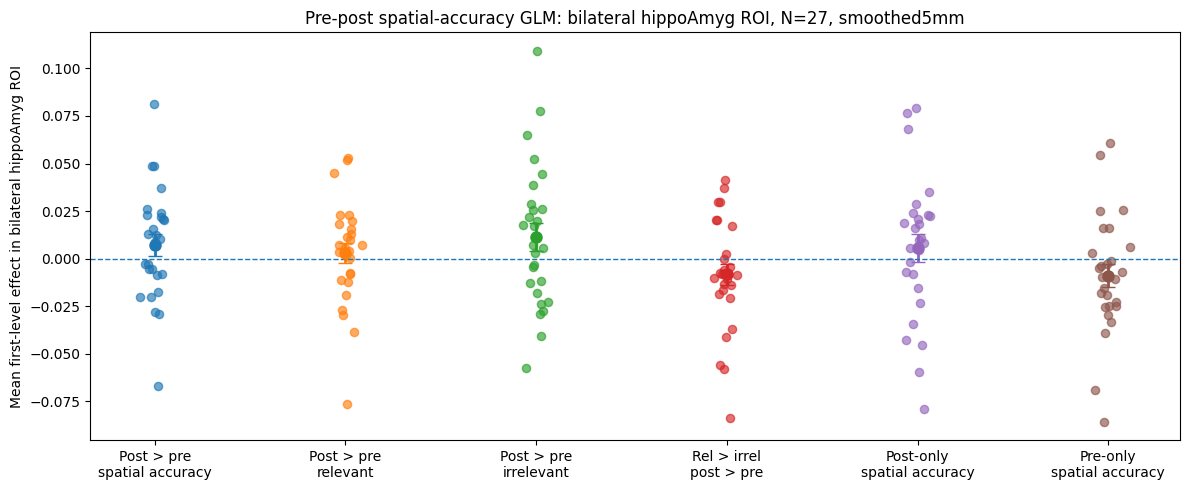

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/roi/figures/pre_post_bilateral_hippoAmyg_effects_smoothed5mm.png


In [33]:
# ============================================================
# 26. Plot bilateral hippoAmyg pre-post ROI effects
# ============================================================

bilateral_df = pre_post_roi_effects.loc[
    pre_post_roi_effects["roi"] == "bilateral_hippoAmyg"
].copy()

contrast_order = [
    "post_gt_pre_spatial_accuracy",
    "post_gt_pre_relevant_spatial_accuracy",
    "post_gt_pre_irrelevant_spatial_accuracy",
    "relevant_gt_irrelevant_post_gt_pre_spatial_accuracy",
    "post_spatial_accuracy_positive",
    "pre_spatial_accuracy_positive",
]

contrast_labels_short = {
    "post_gt_pre_spatial_accuracy": "Post > pre\nspatial accuracy",
    "post_gt_pre_relevant_spatial_accuracy": "Post > pre\nrelevant",
    "post_gt_pre_irrelevant_spatial_accuracy": "Post > pre\nirrelevant",
    "relevant_gt_irrelevant_post_gt_pre_spatial_accuracy": "Rel > irrel\npost > pre",
    "post_spatial_accuracy_positive": "Post-only\nspatial accuracy",
    "pre_spatial_accuracy_positive": "Pre-only\nspatial accuracy",
}

fig, ax = plt.subplots(figsize=(12, 5))

x_positions = np.arange(len(contrast_order))
rng = np.random.default_rng(42)

for i, contrast_name in enumerate(contrast_order):
    values = bilateral_df.loc[
        bilateral_df["contrast"] == contrast_name,
        "mean_effect",
    ].values
    
    jitter = rng.normal(loc=0, scale=0.04, size=len(values))
    
    ax.scatter(
        np.full(len(values), x_positions[i]) + jitter,
        values,
        alpha=0.65,
        s=35,
    )
    
    ax.errorbar(
        x_positions[i],
        np.mean(values),
        yerr=np.std(values, ddof=1) / np.sqrt(len(values)),
        marker="o",
        markersize=8,
        capsize=5,
        linewidth=2,
    )

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xticks(x_positions)
ax.set_xticklabels([contrast_labels_short[c] for c in contrast_order])
ax.set_ylabel("Mean first-level effect in bilateral hippoAmyg ROI")
ax.set_title(f"Pre-post spatial-accuracy GLM: bilateral hippoAmyg ROI, N={len(pre_post_subjects)}, {SMOOTHING_LABEL}")

plt.tight_layout()

out_path = ROI_FIG_DIR / f"pre_post_bilateral_hippoAmyg_effects_{SMOOTHING_LABEL}.png"
fig.savefig(out_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

In [34]:
# ============================================================
# 27. Sensitivity ROI analysis excluding high-motion subjects
# Exclude sub-P19 and sub-P21
# ============================================================

HIGH_MOTION_SUBJECTS = ["sub-P19", "sub-P21"]

sensitivity_roi_effects = pre_post_roi_effects.loc[
    ~pre_post_roi_effects["subject"].isin(HIGH_MOTION_SUBJECTS)
].copy()

print("Original N:", pre_post_roi_effects["subject"].nunique())
print("Sensitivity N:", sensitivity_roi_effects["subject"].nunique())
print("Excluded:", HIGH_MOTION_SUBJECTS)

sensitivity_roi_summary_rows = []

for (contrast_name, roi_name), df in sensitivity_roi_effects.groupby(["contrast", "roi"]):
    values = df["mean_effect"].dropna().values
    n = len(values)
    
    mean_effect = float(np.mean(values))
    sd_effect = float(np.std(values, ddof=1))
    sem_effect = float(sd_effect / np.sqrt(n))
    
    t_stat, p_two_sided = stats.ttest_1samp(values, popmean=0.0)
    
    if t_stat >= 0:
        p_one_sided_positive = p_two_sided / 2
    else:
        p_one_sided_positive = 1 - (p_two_sided / 2)
    
    n_positive = int(np.sum(values > 0))
    
    sensitivity_roi_summary_rows.append({
        "contrast": contrast_name,
        "priority": contrast_priority[contrast_name],
        "roi": roi_name,
        "n_subjects": n,
        "mean_effect": mean_effect,
        "sd_effect": sd_effect,
        "sem_effect": sem_effect,
        "t_stat": float(t_stat),
        "p_two_sided": float(p_two_sided),
        "p_one_sided_positive": float(p_one_sided_positive),
        "n_positive": n_positive,
        "proportion_positive": n_positive / n,
        "excluded_subjects": ",".join(HIGH_MOTION_SUBJECTS),
    })

sensitivity_pre_post_roi_summary = pd.DataFrame(sensitivity_roi_summary_rows)

sensitivity_pre_post_roi_summary = sensitivity_pre_post_roi_summary.sort_values(
    ["priority", "contrast", "roi"]
).reset_index(drop=True)

display(sensitivity_pre_post_roi_summary)

sensitivity_roi_summary_path = (
    ROI_TABLE_DIR
    / f"pre_post_supervisor_hippoamyg_group_summary_no_high_motion_{SMOOTHING_LABEL}.csv"
)

sensitivity_pre_post_roi_summary.to_csv(sensitivity_roi_summary_path, index=False)

print("Saved:", sensitivity_roi_summary_path)

Original N: 27
Sensitivity N: 25
Excluded: ['sub-P19', 'sub-P21']


,contrast,priority,roi,n_subjects,mean_effect,sd_effect,sem_effect,t_stat,p_two_sided,p_one_sided_positive,n_positive,proportion_positive,excluded_subjects
0,post_spatial_accuracy_positive,descriptive_post_only_check,bilateral_hippoAmyg,25,0.006481,0.039057,0.007811,0.829630,0.414924,0.207462,16,0.64,"sub-P19,sub-P21"
1,post_spatial_accuracy_positive,descriptive_post_only_check,left_hippoAmyg,25,0.004375,0.042458,0.008492,0.515169,0.611147,0.305574,14,0.56,"sub-P19,sub-P21"
2,post_spatial_accuracy_positive,descriptive_post_only_check,right_hippoAmyg,25,0.008524,0.038880,0.007776,1.096238,0.283853,0.141927,17,0.68,"sub-P19,sub-P21"
3,pre_spatial_accuracy_positive,descriptive_pre_only_check,bilateral_hippoAmyg,25,-0.011715,0.029257,0.005851,-2.002071,0.056702,0.971649,7,0.28,"sub-P19,sub-P21"
4,pre_spatial_accuracy_positive,descriptive_pre_only_check,left_hippoAmyg,25,-0.010735,0.028392,0.005678,-1.890563,0.070817,0.964592,7,0.28,"sub-P19,sub-P21"
5,pre_spatial_accuracy_positive,descriptive_pre_only_check,right_hippoAmyg,25,-0.012640,0.031476,0.006295,-2.007817,0.056047,0.971976,9,0.36,"sub-P19,sub-P21"
6,post_gt_pre_spatial_accuracy,primary,bilateral_hippoAmyg,25,0.009098,0.029678,0.005936,1.532753,0.138414,0.069207,15,0.60,"sub-P19,sub-P21"
7,post_gt_pre_spatial_accuracy,primary,left_hippoAmyg,25,0.007555,0.029363,0.005873,1.286477,0.210549,0.105274,15,0.60,"sub-P19,sub-P21"
8,post_gt_pre_spatial_accuracy,primary,right_hippoAmyg,25,0.010582,0.031453,0.006291,1.682169,0.105504,0.052752,16,0.64,"sub-P19,sub-P21"
9,post_gt_pre_irrelevant_spatial_accuracy,secondary_condition_specific,bilateral_hippoAmyg,25,0.013531,0.038453,0.007691,1.759479,0.091240,0.045620,16,0.64,"sub-P19,sub-P21"


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/roi/tables/pre_post_supervisor_hippoamyg_group_summary_no_high_motion_smoothed5mm.csv


In [35]:
# ============================================================
# 28. Compact final summary of pre-post spatial-accuracy GLM
# ============================================================

summary_contrasts = [
    "post_gt_pre_spatial_accuracy",
    "post_gt_pre_relevant_spatial_accuracy",
    "post_gt_pre_irrelevant_spatial_accuracy",
    "relevant_gt_irrelevant_post_gt_pre_spatial_accuracy",
]

summary_rois = [
    "bilateral_hippoAmyg",
    "left_hippoAmyg",
    "right_hippoAmyg",
]

full_roi_compact = pre_post_roi_summary.loc[
    pre_post_roi_summary["contrast"].isin(summary_contrasts)
    & pre_post_roi_summary["roi"].isin(summary_rois)
].copy()

full_roi_compact["sample"] = "full_N27"

sensitivity_roi_compact = sensitivity_pre_post_roi_summary.loc[
    sensitivity_pre_post_roi_summary["contrast"].isin(summary_contrasts)
    & sensitivity_pre_post_roi_summary["roi"].isin(summary_rois)
].copy()

sensitivity_roi_compact["sample"] = "no_high_motion_N25"

compact_roi_summary = pd.concat(
    [full_roi_compact, sensitivity_roi_compact],
    ignore_index=True,
)

compact_roi_summary = compact_roi_summary[
    [
        "sample",
        "contrast",
        "priority",
        "roi",
        "n_subjects",
        "mean_effect",
        "sem_effect",
        "t_stat",
        "p_two_sided",
        "p_one_sided_positive",
        "n_positive",
        "proportion_positive",
    ]
].copy()

compact_roi_summary = compact_roi_summary.sort_values(
    ["contrast", "roi", "sample"]
).reset_index(drop=True)

display(compact_roi_summary)

compact_roi_summary_path = (
    ROI_TABLE_DIR
    / f"pre_post_compact_roi_summary_full_and_sensitivity_{SMOOTHING_LABEL}.csv"
)

compact_roi_summary.to_csv(compact_roi_summary_path, index=False)

print("Saved:", compact_roi_summary_path)


# Whole-brain compact correction outcome
whole_brain_compact = threshold_summary.loc[
    threshold_summary["contrast"].isin(summary_contrasts)
].copy()

whole_brain_compact = whole_brain_compact[
    [
        "contrast",
        "priority",
        "threshold_label",
        "height_control",
        "alpha",
        "z_threshold",
        "n_nonzero_voxels",
        "max_z",
    ]
].copy()

display(
    whole_brain_compact.sort_values(
        ["contrast", "threshold_label"]
    )
)

whole_brain_compact_path = (
    TABLE_DIR
    / f"pre_post_compact_whole_brain_threshold_summary_{SMOOTHING_LABEL}.csv"
)

whole_brain_compact.to_csv(whole_brain_compact_path, index=False)

print("Saved:", whole_brain_compact_path)

,sample,contrast,priority,roi,n_subjects,mean_effect,sem_effect,t_stat,p_two_sided,p_one_sided_positive,n_positive,proportion_positive
0,full_N27,post_gt_pre_irrelevant_spatial_accuracy,secondary_condition_specific,bilateral_hippoAmyg,27,0.011434,0.007259,1.575178,0.127306,0.063653,16,0.592593
1,no_high_motion_N25,post_gt_pre_irrelevant_spatial_accuracy,secondary_condition_specific,bilateral_hippoAmyg,25,0.013531,0.007691,1.759479,0.091240,0.045620,16,0.640000
2,full_N27,post_gt_pre_irrelevant_spatial_accuracy,secondary_condition_specific,left_hippoAmyg,27,0.009435,0.007086,1.331524,0.194574,0.097287,17,0.629630
3,no_high_motion_N25,post_gt_pre_irrelevant_spatial_accuracy,secondary_condition_specific,left_hippoAmyg,25,0.010696,0.007605,1.406543,0.172380,0.086190,17,0.680000
4,full_N27,post_gt_pre_irrelevant_spatial_accuracy,secondary_condition_specific,right_hippoAmyg,27,0.013293,0.008078,1.645523,0.111899,0.055950,15,0.555556
5,no_high_motion_N25,post_gt_pre_irrelevant_spatial_accuracy,secondary_condition_specific,right_hippoAmyg,25,0.016202,0.008458,1.915665,0.067396,0.033698,15,0.600000
6,full_N27,post_gt_pre_relevant_spatial_accuracy,secondary_condition_specific,bilateral_hippoAmyg,27,0.003098,0.005273,0.587389,0.562010,0.281005,18,0.666667
7,no_high_motion_N25,post_gt_pre_relevant_spatial_accuracy,secondary_condition_specific,bilateral_hippoAmyg,25,0.004664,0.005434,0.858252,0.399244,0.199622,17,0.680000
8,full_N27,post_gt_pre_relevant_spatial_accuracy,secondary_condition_specific,left_hippoAmyg,27,0.005163,0.005578,0.925638,0.363147,0.181573,15,0.555556
9,no_high_motion_N25,post_gt_pre_relevant_spatial_accuracy,secondary_condition_specific,left_hippoAmyg,25,0.004414,0.005867,0.752308,0.459181,0.229591,14,0.560000


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/roi/tables/pre_post_compact_roi_summary_full_and_sensitivity_smoothed5mm.csv


,contrast,priority,threshold_label,height_control,alpha,z_threshold,n_nonzero_voxels,max_z
11,post_gt_pre_irrelevant_spatial_accuracy,secondary_condition_specific,bonferroni_p05_one_sided,bonferroni,0.050,4.943085,0,NaN
9,post_gt_pre_irrelevant_spatial_accuracy,secondary_condition_specific,fdr_q05_one_sided,fdr,0.050,inf,0,NaN
10,post_gt_pre_irrelevant_spatial_accuracy,secondary_condition_specific,fdr_q10_one_sided,fdr,0.100,inf,0,NaN
8,post_gt_pre_irrelevant_spatial_accuracy,secondary_condition_specific,uncorrected_p001_one_sided,uncorrected,0.001,3.000000,44,3.995424
7,post_gt_pre_relevant_spatial_accuracy,secondary_condition_specific,bonferroni_p05_one_sided,bonferroni,0.050,4.943085,0,NaN
5,post_gt_pre_relevant_spatial_accuracy,secondary_condition_specific,fdr_q05_one_sided,fdr,0.050,inf,0,NaN
6,post_gt_pre_relevant_spatial_accuracy,secondary_condition_specific,fdr_q10_one_sided,fdr,0.100,inf,0,NaN
4,post_gt_pre_relevant_spatial_accuracy,secondary_condition_specific,uncorrected_p001_one_sided,uncorrected,0.001,3.000000,39,4.085502
3,post_gt_pre_spatial_accuracy,primary,bonferroni_p05_one_sided,bonferroni,0.050,4.943085,0,NaN
1,post_gt_pre_spatial_accuracy,primary,fdr_q05_one_sided,fdr,0.050,inf,0,NaN


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/tables/pre_post_compact_whole_brain_threshold_summary_smoothed5mm.csv


### Pre–post spatial-accuracy GLM conclusion

To test whether image-evoked activity increased after encoding as a function of later spatial memory precision, we estimated a pre–post parametric GLM. For each image, the parametric modulator was the within-subject, condition-centered spatial-accuracy score:

$$
\text{spatial accuracy}_{i} = - \text{spatial error}_{i}
$$

and the primary contrast tested whether the spatial-accuracy slope was larger during post-viewing than during pre-viewing:

$$
\left(\beta_{\text{post,relevant}} + \beta_{\text{post,irrelevant}}\right)/2
-
\left(\beta_{\text{pre,relevant}} + \beta_{\text{pre,irrelevant}}\right)/2
> 0.
$$

At the whole-brain level, the primary contrast did not survive correction for multiple comparisons. No voxels survived FDR correction at $$q < .05$$, FDR correction at $$q < .10$$, or Bonferroni correction. Exploratory uncorrected effects were present at $$p < .001$$ one-sided, but these should not be interpreted as confirmatory evidence.

In the a priori bilateral hippoAmyg ROI, the primary pre–post spatial-accuracy effect was positive but not statistically reliable in the full sample:

$$
M = 0.0073,\quad t(26) = 1.28,\quad p_{\text{two-sided}} = .212,\quad p_{\text{one-sided}} = .106.
$$

After excluding the high-motion subjects `sub-P19` and `sub-P21`, the same effect became numerically stronger but remained below conventional two-sided significance:

$$
M = 0.0091,\quad t(24) = 1.53,\quad p_{\text{two-sided}} = .138,\quad p_{\text{one-sided}} = .069.
$$

The strongest exploratory ROI pattern appeared for goal-irrelevant images. In the no-high-motion sensitivity sample, the post > pre spatial-accuracy effect for irrelevant images was positive in bilateral hippoAmyg,

$$
M = 0.0135,\quad t(24) = 1.76,\quad p_{\text{two-sided}} = .091,\quad p_{\text{one-sided}} = .046,
$$

and was numerically strongest in right hippoAmyg,

$$
M = 0.0162,\quad t(24) = 1.92,\quad p_{\text{two-sided}} = .067,\quad p_{\text{one-sided}} = .034.
$$

Because this was a secondary condition-specific analysis and was not corrected across contrasts and ROIs, it should be interpreted cautiously. Overall, the pre–post analysis does not provide confirmatory evidence that hippoAmyg activity increases after encoding as a function of later spatial precision. However, the ROI estimates are directionally compatible with the hypothesis and suggest a weak exploratory pattern, especially for goal-irrelevant images.

Peak coordinate used for plotting: [ 24.   -2.  -30.5]
Right ROI max z: 3.159017575192167
Bilateral ROI max z: 3.159017575192167


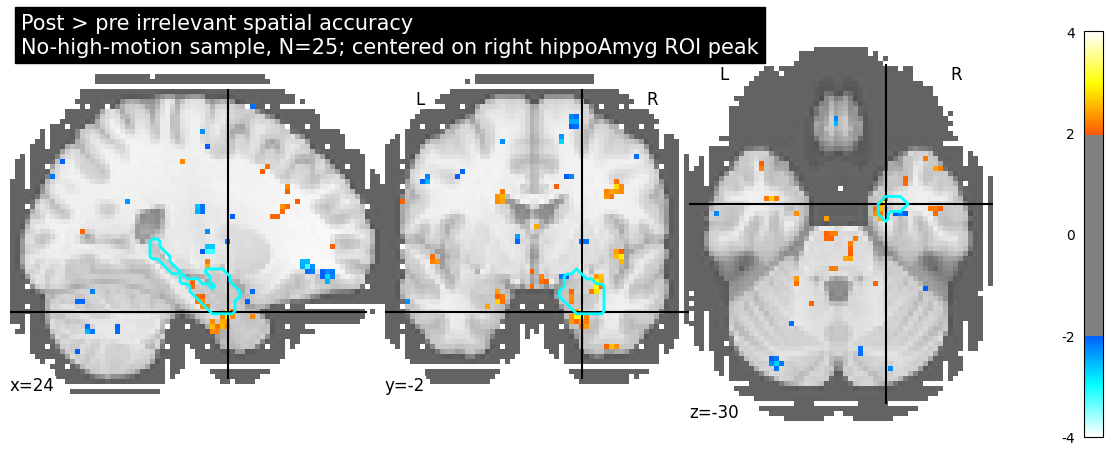

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/figures/roi_cluster_visualization/SUPERVISOR_group_post_gt_pre_irrelevant_spatial_accuracy_no_high_motion_N25_right_hippoAmyg_peak_MNI_background.png


In [37]:
# ============================================================
# 30. Cleaner supervisor figure with MNI anatomical background
# Strongest exploratory ROI pattern:
# post > pre irrelevant spatial accuracy, no-high-motion N=25
# ============================================================

from nilearn.datasets import load_mni152_template
from nilearn.plotting import plot_stat_map
from nilearn.image import resample_to_img
import matplotlib.pyplot as plt

# Load MNI anatomical background
mni_template = load_mni152_template(resolution=2)

# Resample background to the group z-map space if needed
mni_template_resampled = resample_to_img(
    mni_template,
    group_z_img_no_high_motion,
    interpolation="continuous",
    force_resample=True,
    copy_header=True,
)

# Use the peak coordinate already found inside the right hippoAmyg ROI
print("Peak coordinate used for plotting:", peak_coord)
print("Right ROI max z:", right_roi_max_z)
print("Bilateral ROI max z:", bilateral_roi_max_z)

# ------------------------------------------------------------
# Main supervisor figure:
# whole-brain z-map, centered on right hippoAmyg ROI peak,
# with right hippoAmyg contour overlaid
# ------------------------------------------------------------

fig = plt.figure(figsize=(11, 4.5))

display = plot_stat_map(
    group_z_img_no_high_motion,
    bg_img=mni_template_resampled,
    display_mode="ortho",
    cut_coords=peak_coord,
    threshold=2.0,
    vmax=4.0,
    cmap="cold_hot",
    black_bg=False,
    title=(
        "Post > pre irrelevant spatial accuracy\n"
        f"No-high-motion sample, N={len(plot_subjects)}; centered on right hippoAmyg ROI peak"
    ),
    figure=fig,
)

display.add_contours(
    right_group_roi,
    levels=[0.5],
    colors=["cyan"],
    linewidths=2.0,
)

supervisor_fig_path = (
    PLOT_DIR
    / f"SUPERVISOR_group_{PLOT_CONTRAST}_{PLOT_SAMPLE_LABEL}_right_hippoAmyg_peak_MNI_background.png"
)

fig.savefig(supervisor_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", supervisor_fig_path)

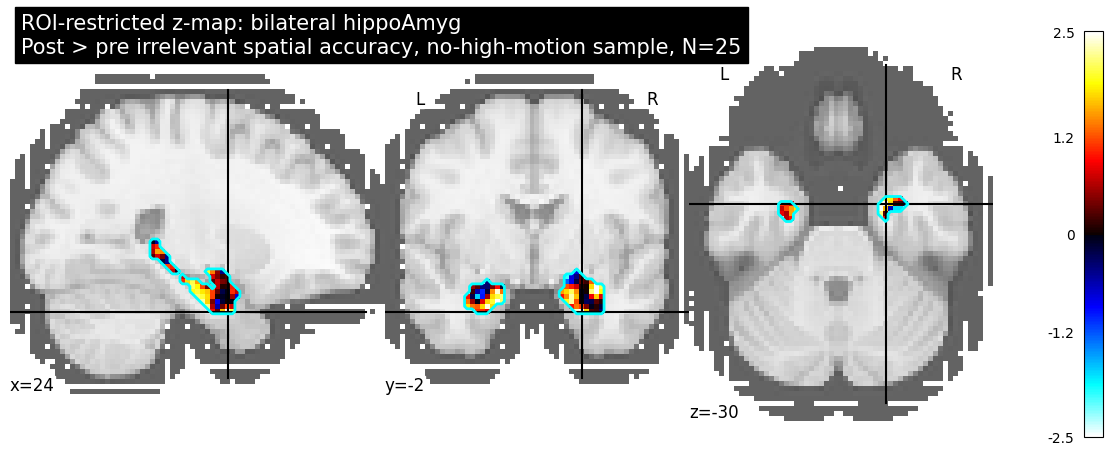

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/figures/roi_cluster_visualization/SUPERVISOR_group_post_gt_pre_irrelevant_spatial_accuracy_no_high_motion_N25_bilateral_hippoAmyg_ROI_restricted_MNI_background.png


In [38]:
# ============================================================
# 31. ROI-focused figure on MNI anatomical background
# Shows only z-values inside bilateral hippoAmyg ROI
# ============================================================

fig = plt.figure(figsize=(11, 4.5))

display = plot_stat_map(
    roi_restricted_z_img,
    bg_img=mni_template_resampled,
    display_mode="ortho",
    cut_coords=peak_coord,
    threshold=0.0,
    vmax=2.5,
    cmap="cold_hot",
    black_bg=False,
    title=(
        "ROI-restricted z-map: bilateral hippoAmyg\n"
        f"Post > pre irrelevant spatial accuracy, no-high-motion sample, N={len(plot_subjects)}"
    ),
    figure=fig,
)

display.add_contours(
    bilateral_group_roi,
    levels=[0.5],
    colors=["cyan"],
    linewidths=2.0,
)

roi_supervisor_fig_path = (
    PLOT_DIR
    / f"SUPERVISOR_group_{PLOT_CONTRAST}_{PLOT_SAMPLE_LABEL}_bilateral_hippoAmyg_ROI_restricted_MNI_background.png"
)

fig.savefig(roi_supervisor_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", roi_supervisor_fig_path)

Main contrast z-map:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/second_level_from_smoothed5mm/maps/group_pre_post_post_gt_pre_spatial_accuracy_from_smoothed5mm_zmap.nii.gz
Exists: True
Whole-brain positive peak voxel: (np.int64(23), np.int64(29), np.int64(19))
Whole-brain positive peak coordinate: [-18.5 -39.5 -28. ]
Whole-brain positive peak z: 3.8447139263153076


/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


Saved interactive viewer:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/figures/interactive/INTERACTIVE_main_post_gt_pre_spatial_accuracy_smoothed5mm_zgt233.html



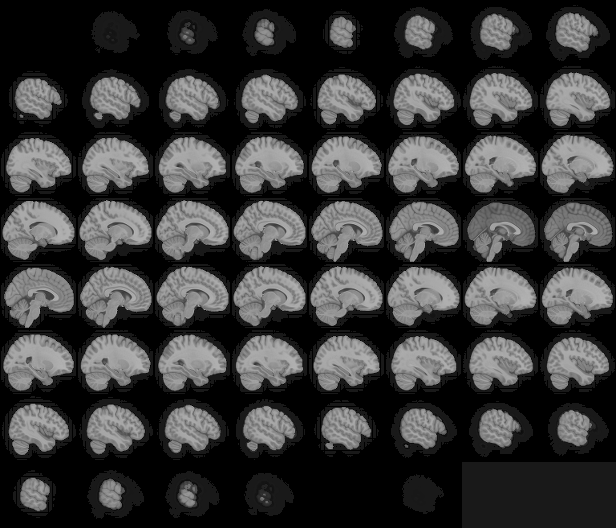
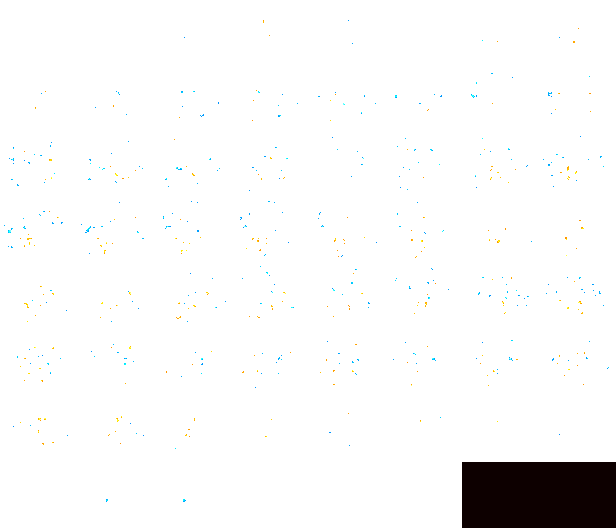

In [39]:
# ============================================================
# 32. Interactive visualization of the main pre-post contrast
# Main contrast: post > pre spatial accuracy
# ============================================================

from nilearn.plotting import view_img, plot_stat_map
from nilearn.datasets import load_mni152_template
from nilearn.image import resample_to_img
import webbrowser

INTERACTIVE_DIR = OUT_DIR / "figures" / "interactive"
INTERACTIVE_DIR.mkdir(parents=True, exist_ok=True)

MAIN_CONTRAST = "post_gt_pre_spatial_accuracy"

main_group_z_path = get_group_z_map_path(MAIN_CONTRAST)
main_group_z_img = load_img(str(main_group_z_path))

print("Main contrast z-map:")
print(main_group_z_path)
print("Exists:", main_group_z_path.exists())

# Anatomical background
mni_template = load_mni152_template(resolution=2)

mni_template_resampled = resample_to_img(
    mni_template,
    main_group_z_img,
    interpolation="continuous",
    force_resample=True,
    copy_header=True,
)

# ------------------------------------------------------------
# Find the peak positive voxel in the whole-brain map
# ------------------------------------------------------------

z_data = main_group_z_img.get_fdata()

finite_positive = np.where(np.isfinite(z_data), z_data, -np.inf)
peak_voxel = np.unravel_index(np.nanargmax(finite_positive), finite_positive.shape)
peak_coord = nib.affines.apply_affine(main_group_z_img.affine, peak_voxel)
peak_z = z_data[peak_voxel]

print("Whole-brain positive peak voxel:", peak_voxel)
print("Whole-brain positive peak coordinate:", peak_coord)
print("Whole-brain positive peak z:", peak_z)

# ------------------------------------------------------------
# Interactive whole-brain viewer
# ------------------------------------------------------------
# threshold=2.33 gives an exploratory p < .01 one-sided-ish visualization.
# threshold=3.0 corresponds approximately to p < .001 one-sided.
# Since the corrected result is null, this is explicitly exploratory.

interactive_view = view_img(
    main_group_z_img,
    bg_img=mni_template_resampled,
    threshold=2.33,
    vmax=4.0,
    symmetric_cmap=True,
    cmap="cold_hot",
    title=(
        "Main contrast: post > pre spatial accuracy "
        f"(N={len(pre_post_subjects)}, exploratory z > 2.33)"
    ),
)

interactive_html_path = (
    INTERACTIVE_DIR
    / f"INTERACTIVE_main_{MAIN_CONTRAST}_{SMOOTHING_LABEL}_zgt233.html"
)

interactive_view.save_as_html(str(interactive_html_path))

print("Saved interactive viewer:")
print(interactive_html_path)

interactive_view

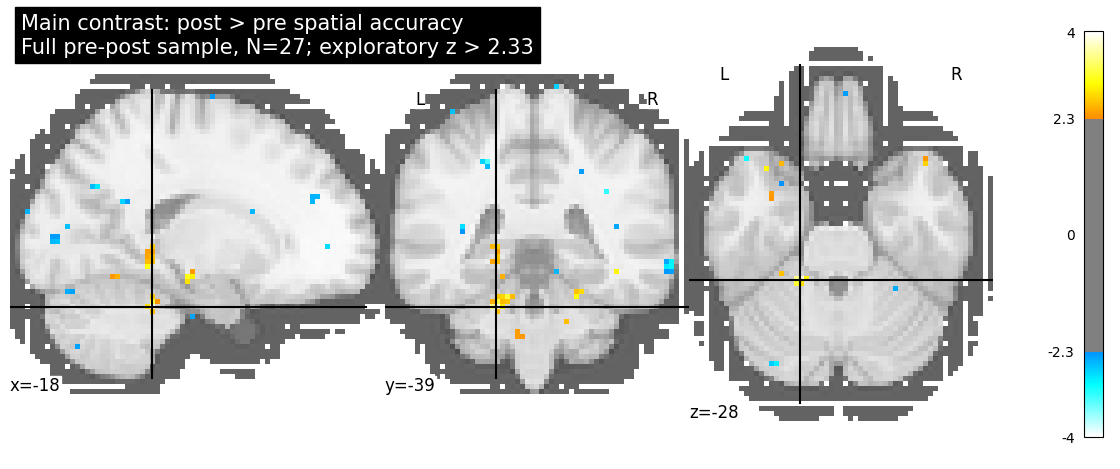

Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/figures/main_contrast/SUPERVISOR_main_post_gt_pre_spatial_accuracy_smoothed5mm_zgt233_peak.png


In [40]:
# ============================================================
# 33. Static supervisor figure for main pre-post contrast
# ============================================================

STATIC_MAIN_DIR = OUT_DIR / "figures" / "main_contrast"
STATIC_MAIN_DIR.mkdir(parents=True, exist_ok=True)

fig = plt.figure(figsize=(11, 4.5))

display = plot_stat_map(
    main_group_z_img,
    bg_img=mni_template_resampled,
    display_mode="ortho",
    cut_coords=peak_coord,
    threshold=2.33,
    vmax=4.0,
    cmap="cold_hot",
    black_bg=False,
    title=(
        "Main contrast: post > pre spatial accuracy\n"
        f"Full pre-post sample, N={len(pre_post_subjects)}; exploratory z > 2.33"
    ),
    figure=fig,
)

main_static_fig_path = (
    STATIC_MAIN_DIR
    / f"SUPERVISOR_main_{MAIN_CONTRAST}_{SMOOTHING_LABEL}_zgt233_peak.png"
)

fig.savefig(main_static_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", main_static_fig_path)

Saved ROI-restricted z-map:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/figures/interactive/main_post_gt_pre_spatial_accuracy_bilateral_hippoAmyg_restricted_smoothed5mm_zmap.nii.gz
Bilateral ROI peak voxel: (np.int64(17), np.int64(38), np.int64(23))
Bilateral ROI peak coordinate: [-33.5 -17.  -18. ]
Bilateral ROI peak z: 3.1964240074157715
Saved interactive ROI viewer:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_spatial_accuracy_parametric/figures/interactive/INTERACTIVE_main_post_gt_pre_spatial_accuracy_bilateral_hippoAmyg_ROI_smoothed5mm.html



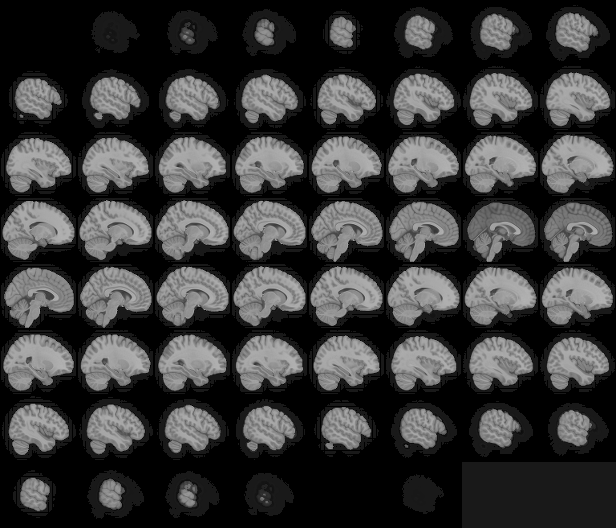
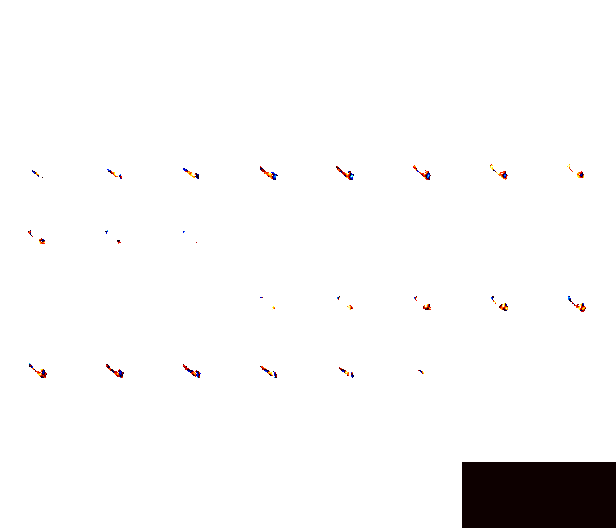

In [41]:
# ============================================================
# 34. Interactive ROI-restricted viewer for main pre-post contrast
# ============================================================

# Reuse or rebuild the bilateral group ROI.
# If bilateral_group_roi already exists from the previous cells, this will use it.
# Otherwise, rebuild it from subject-specific masks for the full N=27 sample.

if "bilateral_group_roi" not in globals():
    reference_img = main_group_z_img
    
    left_masks = []
    right_masks = []
    
    for subject in pre_post_subjects:
        left_path = find_supervisor_hippoamyg_mask(subject, "L")
        right_path = find_supervisor_hippoamyg_mask(subject, "R")
        
        assert left_path is not None, f"Missing left ROI mask for {subject}"
        assert right_path is not None, f"Missing right ROI mask for {subject}"
        
        left_img = nib.load(str(left_path))
        right_img = nib.load(str(right_path))
        
        left_bin = nib.Nifti1Image(
            (left_img.get_fdata() > 0).astype(np.uint8),
            affine=left_img.affine,
            header=left_img.header,
        )
        
        right_bin = nib.Nifti1Image(
            (right_img.get_fdata() > 0).astype(np.uint8),
            affine=right_img.affine,
            header=right_img.header,
        )
        
        left_resampled = resample_to_img(
            left_bin,
            reference_img,
            interpolation="nearest",
            force_resample=True,
            copy_header=True,
        )
        
        right_resampled = resample_to_img(
            right_bin,
            reference_img,
            interpolation="nearest",
            force_resample=True,
            copy_header=True,
        )
        
        left_masks.append(left_resampled)
        right_masks.append(right_resampled)
    
    left_prob_img = mean_img(left_masks)
    right_prob_img = mean_img(right_masks)
    
    ROI_PROB_THRESHOLD = 0.25
    
    bilateral_group_roi = math_img(
        f"(left > {ROI_PROB_THRESHOLD}) | (right > {ROI_PROB_THRESHOLD})",
        left=left_prob_img,
        right=right_prob_img,
    )

# Restrict main z-map to bilateral hippoAmyg ROI
main_z_data = main_group_z_img.get_fdata()
bilateral_roi_data = bilateral_group_roi.get_fdata() > 0

main_roi_restricted_z_data = np.where(bilateral_roi_data, main_z_data, 0)

main_roi_restricted_z_img = nib.Nifti1Image(
    main_roi_restricted_z_data,
    affine=main_group_z_img.affine,
    header=main_group_z_img.header,
)

main_roi_restricted_z_path = (
    INTERACTIVE_DIR
    / f"main_{MAIN_CONTRAST}_bilateral_hippoAmyg_restricted_{SMOOTHING_LABEL}_zmap.nii.gz"
)

main_roi_restricted_z_img.to_filename(str(main_roi_restricted_z_path))

print("Saved ROI-restricted z-map:")
print(main_roi_restricted_z_path)

# Find peak inside bilateral ROI
masked_main_z = np.where(bilateral_roi_data, main_z_data, -np.inf)
roi_peak_voxel = np.unravel_index(np.nanargmax(masked_main_z), masked_main_z.shape)
roi_peak_coord = nib.affines.apply_affine(main_group_z_img.affine, roi_peak_voxel)
roi_peak_z = main_z_data[roi_peak_voxel]

print("Bilateral ROI peak voxel:", roi_peak_voxel)
print("Bilateral ROI peak coordinate:", roi_peak_coord)
print("Bilateral ROI peak z:", roi_peak_z)

# Interactive ROI viewer
main_roi_interactive_view = view_img(
    main_roi_restricted_z_img,
    bg_img=mni_template_resampled,
    threshold=0.0,
    vmax=2.5,
    symmetric_cmap=True,
    cmap="cold_hot",
    title=(
        "Main contrast: post > pre spatial accuracy, "
        "bilateral hippoAmyg ROI-restricted"
    ),
)

main_roi_interactive_html_path = (
    INTERACTIVE_DIR
    / f"INTERACTIVE_main_{MAIN_CONTRAST}_bilateral_hippoAmyg_ROI_{SMOOTHING_LABEL}.html"
)

main_roi_interactive_view.save_as_html(str(main_roi_interactive_html_path))

print("Saved interactive ROI viewer:")
print(main_roi_interactive_html_path)

main_roi_interactive_view

replot encore whole brain